# 金融对话数值推理模型：SFT → 轻量 DPO / GRPO → benchmark 评估

目标：训练一个面向 **金融对话数值推理** 的 reasoning model。

整体闭环：
- **SFT-1（FinQA）**：先学习表文混合数值推理与程序监督
- **SFT-2（ConvFinQA）**：再学习多轮对话中的 follow-up 数值推理
- **DPO（可选）**：小规模优化表达质量、结构和少废话
- **GRPO（推荐）**：基于可验证 reward 优化答案正确性、程序一致性与结构约束
- **benchmark 评估**：`FinQA / ConvFinQA + CFLUE + FinanceBench + AdaptLLM/finance-tasks`

本 Notebook 复用 MedicalGPT 的训练框架：
- 数据格式遵循 `docs/datasets.md`
- pipeline 参考 `run_training_dpo_pipeline.ipynb`


## 环境准备

如果你在全新环境运行，请先安装依赖；已按项目 README 配好可跳过。


In [ ]:
%pip install -r requirements.txt --upgrade

Looking in indexes: http://mirrors.aliyun.com/pypi/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 38.5 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.0/557.0 kB 32.3 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.7 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 11.7 MB/s  0:00:00 eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 9.7 MB/s  0:00:00m eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 10.3 MB/s  0:00:00eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 630.8/630.8 kB 14.0 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 13.0 MB/s  0:00:00 eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 10.4 MB/s  0:00:01 eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 770.3/770.3 kB 58.5 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.6/530.6 MB 9.6 MB/s  0:00:540:00:0100:02
     ━━━━━━━

In [ ]:
%pip install modelscope


Looking in indexes: http://mirrors.aliyun.com/pypi/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 10.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [modelscope]8 [modelscope]


In [6]:
# HF Mirror（可选）
import os
HF_ENDPOINT = "https://hf-mirror.com"
os.environ["HF_ENDPOINT"] = HF_ENDPOINT
print("HF_ENDPOINT:", os.getenv("HF_ENDPOINT"))


HF_ENDPOINT: https://hf-mirror.com


## 任务配置

这里把配置拆成五部分：
1. 阶段一数据 `SFT-1 (FinQA)`
2. 阶段二数据 `SFT-2 (ConvFinQA)`
3. 原始数据下载缓存目录
4. 转换 / 清洗 / 混合目录
5. 训练与评估输出目录


In [2]:
from pathlib import Path
import json
import random
from itertools import islice

BASE_MODEL = "/root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct"

TEMPLATE_NAME = "qwen"
RANDOM_SEED = 42
FORCE_REDOWNLOAD_RAW = False

# ==== 根路径统一配置（数据盘） ====
DISK_ROOT = Path("/root/autodl-tmp")
DATA_DIR = DISK_ROOT / "data" / "financial_reasoning"
OUTPUT_ROOT = DISK_ROOT / "outputs" / "financial_reasoning"

RAW_CACHE_DIR = DATA_DIR / "raw"
SFT1_SFT_DIR = DATA_DIR / "sft1_sharegpt"
SFT2_SFT_DIR = DATA_DIR / "sft2_sharegpt"
DPO_DIR = DATA_DIR / "dpo_pairs"
MIXED_DIR = DATA_DIR / "mixed"
CLEAN_DIR = DATA_DIR / "clean"
REPORT_DIR = DATA_DIR / "reports"

SFT1_MIXED_FILE = MIXED_DIR / "train_sft1_mixed.jsonl"
SFT2_MIXED_FILE = MIXED_DIR / "train_sft2_mixed.jsonl"
DPO_MIXED_FILE = DPO_DIR / "train_reasoning_dpo.jsonl"
SFT1_CLEAN_FILE = CLEAN_DIR / "train_sft1_clean.jsonl"
SFT2_CLEAN_FILE = CLEAN_DIR / "train_sft2_clean.jsonl"

SFT1_DIR = CLEAN_DIR / "sft1_dir_strict"
SFT2_DIR = CLEAN_DIR / "sft2_dir_strict"
DPO_TRAIN_DIR = DPO_DIR / "train_dir"

SFT1_AUDIT_DIR = CLEAN_DIR / "audit_sft1"
SFT2_AUDIT_DIR = CLEAN_DIR / "audit_sft2"
SFT1_STRICT_FILE = CLEAN_DIR / "train_sft1_clean_strict.jsonl"
SFT2_STRICT_FILE = CLEAN_DIR / "train_sft2_clean_strict.jsonl"

# 训练/日志输出改到数据盘
SFT1_OUT = OUTPUT_ROOT / "sft1_lora"
SFT1_MERGED_OUT = OUTPUT_ROOT / "sft1_merged"
SFT2_OUT = OUTPUT_ROOT / "sft2_lora"
SFT2_MERGED_OUT = OUTPUT_ROOT / "sft2_merged"
DPO_OUT = OUTPUT_ROOT / "dpo_lora"
DPO_MERGED_OUT = OUTPUT_ROOT / "dpo_merged"
TB_LOG_DIR = OUTPUT_ROOT / "tensorboard"

for d in [
    RAW_CACHE_DIR, SFT1_SFT_DIR, SFT2_SFT_DIR, DPO_DIR, MIXED_DIR, CLEAN_DIR, REPORT_DIR,
    SFT1_DIR, SFT2_DIR, DPO_TRAIN_DIR, SFT1_AUDIT_DIR, SFT2_AUDIT_DIR, OUTPUT_ROOT, TB_LOG_DIR,
    SFT1_OUT, SFT1_MERGED_OUT, SFT2_OUT, SFT2_MERGED_OUT, DPO_OUT, DPO_MERGED_OUT,
]:
    d.mkdir(parents=True, exist_ok=True)

SFT1_TOTAL_BUDGET = 6251
SFT2_EXTRA_BUDGET = 7059
DPO_TOTAL_BUDGET = 4000
MAX_DPO_PER_DATASET = 2000

SFT1_DATA_SPECS = [
    {
        "name": "finqa_train",
        "family": "finqa",
        "source_type": "local",
        "local_path": RAW_CACHE_DIR / "finqa" / "train.json",
        "split": "train",
        "weight": 1.0,
        "max_rows": 6251,
        "description": "阶段一：表格 + 文本 + 程序推理（FinQA）",
    },
]

SFT2_DATA_SPECS = [
    {
        "name": "fingpt_convfinqa_train",
        "family": "convfinqa_turn",
        "source_type": "local",
        "local_path": RAW_CACHE_DIR / "convfinqa_turn" / "train_turn.json",
        "split": "train",
        "weight": 1.0,
        "max_rows": None,
        "description": "阶段二：多轮金融对话 + 数值推理（ConvFinQA）",
    },
]

BENCHMARK_SPECS = [
    {"name": "ConvFinQA_dev", "role": "核心多轮数值推理"},
    {"name": "FinQA_dev", "role": "核心表文混合推理"},
    {"name": "CFLUE", "role": "中文金融泛化"},
    {"name": "FinanceBench", "role": "开放书金融 QA 迁移"},
    {"name": "AdaptLLM/finance-tasks", "role": "补充 benchmark"},
]


def allocate_target_rows(specs, total_budget: int, default_cap: int | None = None):
    if not specs:
        return []
    total_weight = sum(max(float(spec.get("weight", 0.0)), 0.0) for spec in specs)
    if total_weight <= 0:
        raise ValueError("All dataset weights are zero; cannot allocate target_rows.")

    allocated = []
    for spec in specs:
        raw_target = int(round(total_budget * float(spec.get("weight", 0.0)) / total_weight))
        cap = spec.get("max_rows", default_cap)
        if cap is not None:
            raw_target = min(raw_target, int(cap))
        spec = dict(spec)
        spec["target_rows"] = max(raw_target, 0)
        allocated.append(spec)
    return allocated


SFT1_DATA_SPECS = allocate_target_rows(SFT1_DATA_SPECS, SFT1_TOTAL_BUDGET)
SFT2_DATA_SPECS = allocate_target_rows(SFT2_DATA_SPECS, SFT2_EXTRA_BUDGET)

print("DISK_ROOT:", DISK_ROOT)
print("DATA_DIR:", DATA_DIR)
print("OUTPUT_ROOT:", OUTPUT_ROOT)
print("BASE_MODEL:", BASE_MODEL)
print("SFT1_TOTAL_BUDGET:", SFT1_TOTAL_BUDGET)
print("SFT2_EXTRA_BUDGET:", SFT2_EXTRA_BUDGET)
print("DPO_TOTAL_BUDGET:", DPO_TOTAL_BUDGET)
print("SFT1_DATA_SPECS:", json.dumps([{**spec, 'local_path': str(spec.get('local_path', ''))} for spec in SFT1_DATA_SPECS], ensure_ascii=False, indent=2))
print("SFT2_DATA_SPECS:", json.dumps([{**spec, 'local_path': str(spec.get('local_path', ''))} for spec in SFT2_DATA_SPECS], ensure_ascii=False, indent=2))
print("BENCHMARK_SPECS:", json.dumps(BENCHMARK_SPECS, ensure_ascii=False, indent=2))


DISK_ROOT: /root/autodl-tmp
DATA_DIR: /root/autodl-tmp/data/financial_reasoning
OUTPUT_ROOT: /root/autodl-tmp/outputs/financial_reasoning
BASE_MODEL: /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct
SFT1_TOTAL_BUDGET: 6251
SFT2_EXTRA_BUDGET: 7059
DPO_TOTAL_BUDGET: 4000
SFT1_DATA_SPECS: [
  {
    "name": "finqa_train",
    "family": "finqa",
    "source_type": "local",
    "local_path": "/root/autodl-tmp/data/financial_reasoning/raw/finqa/train.json",
    "split": "train",
    "weight": 1.0,
    "max_rows": 6251,
    "description": "阶段一：表格 + 文本 + 程序推理（FinQA）",
    "target_rows": 6251
  }
]
SFT2_DATA_SPECS: [
  {
    "name": "fingpt_convfinqa_train",
    "family": "convfinqa_turn",
    "source_type": "local",
    "local_path": "/root/autodl-tmp/data/financial_reasoning/raw/convfinqa_turn/train_turn.json",
    "split": "train",
    "weight": 1.0,
    "max_rows": null,
    "description": "阶段二：多轮金融对话 + 数值推理（ConvFinQA）",
    "target_rows": 7059
  }
]
BENCHMARK_SPECS: [
  {
    "name": "Con

### 统一任务格式

本次两阶段 SFT 的主训练模板：
- **ConvFinQA**：历史对话 + 当前问题 + 表格/文本上下文 → 分步推理 → 最终答案
- **FinQA**：文本 + 表格 + 问题 → reasoning program / 中间步骤 → 执行结果

MedicalGPT 对数据格式的要求：
- **SFT**：`conversations`
- **DPO**：`question + response_chosen + response_rejected`

> 注：路由器仍支持 `fineval/fiqa_qa` family，但当前 notebook 的 SFT 两阶段不使用它们。


In [3]:
from pprint import pprint

SFT_SCHEMA_EXAMPLE = {
    "conversations": [
        {"from": "human", "value": "历史对话 + 当前问题 + 文本/表格上下文"},
        {"from": "gpt", "value": "问题分析...\n关键证据...\n推理程序...\n最终答案..."},
    ]
}

DPO_SCHEMA_EXAMPLE = {
    "system": "",
    "history": [],
    "question": "统一格式的金融推理问题",
    "response_chosen": "结构化且正确的回答",
    "response_rejected": "答案错误或程序不一致的回答",
}

print("[MedicalGPT SFT schema]")
pprint(SFT_SCHEMA_EXAMPLE, sort_dicts=False)
print("[MedicalGPT DPO schema]")
pprint(DPO_SCHEMA_EXAMPLE, sort_dicts=False)


[MedicalGPT SFT schema]
{'conversations': [{'from': 'human', 'value': '历史对话 + 当前问题 + 文本/表格上下文'},
                   {'from': 'gpt',
                    'value': '问题分析...\n关键证据...\n推理程序...\n最终答案...'}]}
[MedicalGPT DPO schema]
{'system': '',
 'history': [],
 'question': '统一格式的金融推理问题',
 'response_chosen': '结构化且正确的回答',
 'response_rejected': '答案错误或程序不一致的回答'}


In [4]:
print("[Training stages]")
print({
    "SFT-1": [spec["name"] for spec in SFT1_DATA_SPECS],
    "SFT-2": [spec["name"] for spec in SFT2_DATA_SPECS],
    "DPO": "从上述 raw 数据自动构造轻量偏好对",
    "GRPO": "基于格式奖励 + 程序一致性 + 答案正确性",
})


[Training stages]
{'SFT-1': ['finqa_train'], 'SFT-2': ['fingpt_convfinqa_train'], 'DPO': '从上述 raw 数据自动构造轻量偏好对', 'GRPO': '基于格式奖励 + 程序一致性 + 答案正确性'}


## 数据集处理流程



### 下载原始数据到本地缓存

这一阶段只负责下载 raw 数据，避免每次重跑 notebook 都重复下载。
- `url_json`：直接下载官方 JSON 文件
- `hf`：通过 `datasets.load_dataset` 落地到本地 jsonl
- 若缓存已存在且 `FORCE_REDOWNLOAD_RAW=False`，则直接跳过


In [4]:
import json
from datasets import load_dataset

ALL_DATA_SPECS = SFT1_DATA_SPECS + SFT2_DATA_SPECS


def raw_cache_file(spec: dict) -> Path:
    if spec["source_type"] == "local":
        return Path(spec["local_path"])
    return RAW_CACHE_DIR / spec["family"] / f"{spec['name']}.jsonl"

raw_files = {}
for spec in ALL_DATA_SPECS:
    cache_file = raw_cache_file(spec)
    raw_files[spec["name"]] = cache_file
    cache_file.parent.mkdir(parents=True, exist_ok=True)

    if spec["source_type"] == "local":
        if not cache_file.exists():
            raise FileNotFoundError(f"Missing local raw file: {cache_file}")
        print(f"[use local] {spec['name']} -> {cache_file}")
        continue

    if cache_file.exists() and not FORCE_REDOWNLOAD_RAW:
        print(f"[skip] use cached raw file: {cache_file}")
        continue

    print(f"[download] {spec['name']} -> {cache_file}")
    if spec["source_type"] == "hf":
        ds = load_dataset(spec["dataset_name"], split=spec["split"])
        with cache_file.open('w', encoding='utf-8') as f:
            for row in ds:
                f.write(json.dumps(dict(row), ensure_ascii=False) + "\n")
    else:
        raise ValueError(f"Unsupported source_type: {spec['source_type']}")
    print(f"[saved] {cache_file}")


/root/miniconda3/envs/llm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[use local] finqa_train -> /root/autodl-tmp/data/financial_reasoning/raw/finqa/train.json
[use local] fingpt_convfinqa_train -> /root/autodl-tmp/data/financial_reasoning/raw/convfinqa_turn/train_turn.json


### 数据集展示

按你的要求，这里直接展示主干数据集 `ConvFinQA / FinQA` 的前几条 raw 样例。

说明：
- `ConvFinQA` 直接读取你已上传的本地文件：`data/financial_reasoning/raw/convfinqa_turn/train_turn.json`
- `FinQA` 直接读取你已上传的本地文件：`data/financial_reasoning/raw/finqa/train.json`


In [5]:
def show_first_records(path: Path, n: int = 2):
    print(f"\n=== {path} ===")
    with path.open('r', encoding='utf-8') as f:
        data = json.load(f)

    if isinstance(data, list):
        for obj in data[:n]:
            print(json.dumps(obj, ensure_ascii=False, indent=2)[:3000])
    else:
        print(json.dumps(data, ensure_ascii=False, indent=2)[:3000])

print(SFT1_DATA_SPECS)
for spec in SFT1_DATA_SPECS:
    show_first_records(raw_files[spec["name"]], n=2)



[{'name': 'finqa_train', 'family': 'finqa', 'source_type': 'local', 'local_path': PosixPath('/root/autodl-tmp/data/financial_reasoning/raw/finqa/train.json'), 'split': 'train', 'weight': 1.0, 'max_rows': 6251, 'description': '阶段一：表格 + 文本 + 程序推理（FinQA）', 'target_rows': 6251}]

=== /root/autodl-tmp/data/financial_reasoning/raw/finqa/train.json ===
{
  "pre_text": [
    "interest rate to a variable interest rate based on the three-month libor plus 2.05% ( 2.05 % ) ( 2.34% ( 2.34 % ) as of october 31 , 2009 ) .",
    "if libor changes by 100 basis points , our annual interest expense would change by $ 3.8 million .",
    "foreign currency exposure as more fully described in note 2i .",
    "in the notes to consolidated financial statements contained in item 8 of this annual report on form 10-k , we regularly hedge our non-u.s .",
    "dollar-based exposures by entering into forward foreign currency exchange contracts .",
    "the terms of these contracts are for periods matching the durati

In [6]:
# 展示数据规模


### 格式匹配

这一阶段只读取本地 raw 文件：
- `financial_data_router.py --task sft`：转换为 SFT 格式
- `financial_data_router.py --task dpo`：转换为轻量 DPO 格式


In [8]:
import json
import subprocess
import pandas as pd

sft_reports = []
dpo_reports = []

for spec in ALL_DATA_SPECS:
    raw_file = raw_files[spec["name"]]
    out_dir = SFT1_SFT_DIR if spec in SFT1_DATA_SPECS else SFT2_SFT_DIR
    sft_file = out_dir / f"{spec['name']}_sharegpt.jsonl"
    dpo_file = DPO_DIR / f"{spec['name']}_dpo.jsonl"

    sharegpt_cmd = [
        "python", "financial_data_router.py",
        "--task", "sft",
        "--source_file", str(raw_file),
        "--output_file", str(sft_file),
        "--dataset_family", spec["family"],
    ]
    dpo_cmd = [
        "python", "financial_data_router.py",
        "--task", "dpo",
        "--source_file", str(raw_file),
        "--output_file", str(dpo_file),
        "--dataset_family", spec["family"],
        "--seed", str(RANDOM_SEED),
    ]

    print(" ".join(sharegpt_cmd))
    sharegpt_result = subprocess.run(sharegpt_cmd, check=True, capture_output=True, text=True)
    print(sharegpt_result.stdout)
    sft_reports.append(json.loads(sharegpt_result.stdout))

    print(" ".join(dpo_cmd))
    dpo_result = subprocess.run(dpo_cmd, check=True, capture_output=True, text=True)
    print(dpo_result.stdout)
    dpo_reports.append(json.loads(dpo_result.stdout))

print("[SFT conversion reports]")
print(json.dumps(sft_reports, ensure_ascii=False, indent=2))
print("[DPO conversion reports]")
print(json.dumps(dpo_reports, ensure_ascii=False, indent=2))

# DPO post-filter summary table (new fields from financial_data_router.py)
dpo_summary_rows = []
for r in dpo_reports:
    pf = r.get('dpo_post_filter', {})
    dpo_summary_rows.append({
        'dataset_family': r.get('dataset_family', ''),
        'input_rows': r.get('input_rows', 0),
        'saved_rows': r.get('saved_rows', 0),
        'skipped_rows': r.get('skipped_rows', 0),
        'post_filter_input_rows': pf.get('post_filter_input_rows', 0),
        'post_filter_saved_rows': pf.get('post_filter_saved_rows', 0),
        'post_filter_skipped_rows': pf.get('post_filter_skipped_rows', 0),
        'post_filter_duplicate_pair_rows': pf.get('post_filter_duplicate_pair_rows', 0),
        'post_filter_not_comparable_rows': pf.get('post_filter_not_comparable_rows', 0),
        'post_filter_rejected_too_short_rows': pf.get('post_filter_rejected_too_short_rows', 0),
    })

dpo_summary_df = pd.DataFrame(dpo_summary_rows)
print("\\n[DPO post-filter summary table]")
display(dpo_summary_df)

# Flatten per-family metrics for drill-down
family_rows = []
for r in dpo_reports:
    for fam, stats in r.get('per_family', {}).items():
        family_rows.append({
            'dataset_family': r.get('dataset_family', ''),
            'family': fam,
            **stats,
        })

if family_rows:
    family_df = pd.DataFrame(family_rows)
    print("\\n[DPO per-family detail]")
    display(family_df)


python financial_data_router.py --task sft --source_file /root/autodl-tmp/data/financial_reasoning/raw/finqa/train.json --output_file /root/autodl-tmp/data/financial_reasoning/sft1_sharegpt/finqa_train_sharegpt.jsonl --dataset_family finqa
{
  "task": "sft",
  "output_file": "/root/autodl-tmp/data/financial_reasoning/sft1_sharegpt/finqa_train_sharegpt.jsonl",
  "dataset_family": "finqa",
  "input_rows": 6251,
  "saved_rows": 6251,
  "skipped_rows": 0,
  "per_family": {
    "finqa": {
      "input_rows": 6251,
      "saved_rows": 6251,
      "skipped_rows": 0,
      "group_count": 0,
      "dedup_dropped_rows": 0,
      "fallback_selected_rows": 0,
      "build_skipped_rows": 0,
      "post_filter_skipped_rows": 0
    }
  }
}

python financial_data_router.py --task dpo --source_file /root/autodl-tmp/data/financial_reasoning/raw/finqa/train.json --output_file /root/autodl-tmp/data/financial_reasoning/dpo_pairs/finqa_train_dpo.jsonl --dataset_family finqa --seed 42
{
  "task": "dpo",
  "o

,dataset_family,input_rows,saved_rows,skipped_rows,post_filter_input_rows,post_filter_saved_rows,post_filter_skipped_rows,post_filter_duplicate_pair_rows,post_filter_not_comparable_rows,post_filter_rejected_too_short_rows
0,finqa,6251,4924,1327,6251,4924,1327,32,0,1295
1,convfinqa_turn,11104,1859,1165,2096,1859,237,0,0,237


\n[DPO per-family detail]


,dataset_family,family,input_rows,saved_rows,skipped_rows,post_filter_input_rows,post_filter_saved_rows,post_filter_skipped_rows,post_filter_duplicate_pair_rows,post_filter_rejected_too_short_rows,group_count,dedup_dropped_rows,fallback_selected_rows,build_skipped_rows
0,finqa,finqa,6251,4924,1327,6251,4924,1327,32.0,1295,0,0,0,0
1,convfinqa_turn,convfinqa_turn,11104,1859,1165,2096,1859,237,NaN,237,3024,8080,0,928


展示转换后的前几条案例

展示转换后的 `ConvFinQA / FinQA` SFT 样例，确认模板、表格上下文、历史对话和推理程序是否正常。


In [9]:
for spec in SFT1_DATA_SPECS:
    sft_file = SFT1_SFT_DIR / f"{spec['name']}_sharegpt.jsonl"
    print(f"\n=== {spec['name']} converted sample ===")
    with sft_file.open('r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if i >= 2:
                break
            print(json.dumps(json.loads(line), ensure_ascii=False, indent=2)[:3500])



=== finqa_train converted sample ===
{
  "source_dataset": "FinQA",
  "task_type": "financial_table_text_reasoning",
  "record_id": "ADI/2009/page_49.pdf-1",
  "metadata": {
    "program": "divide(3.8, divide(100, 100))",
    "gold_inds": {
      "text_1": "if libor changes by 100 basis points , our annual interest expense would change by $ 3.8 million ."
    }
  },
  "conversations": [
    {
      "from": "human",
      "value": "你是一名金融表文混合推理助手。请结合文本、表格和问题，给出可执行的推理程序与最终答案。\n\n材料（表格前文本）：\n- interest rate to a variable interest rate based on the three-month libor plus 2.05% ( 2.05 % ) ( 2.34% ( 2.34 % ) as of october 31 , 2009 ) .\n- if libor changes by 100 basis points , our annual interest expense would change by $ 3.8 million .\n- foreign currency exposure as more fully described in note 2i .\n- in the notes to consolidated financial statements contained in item 8 of this annual report on form 10-k , we regularly hedge our non-u.s .\n- dollar-based exposures by entering into forward

### 清洗

使用 `clean_sharegpt_dataset.py` 对转换后的 SFT 文件进行统一清洗：
- 去掉空轮次 / 奇数轮次
- 去掉超长样本
- 限制单条样本的上下文长度


In [10]:
def sample_jsonl_records(path: Path, target_rows: int, seed: int = 42):
    with path.open('r', encoding='utf-8') as f:
        records = [line for line in f if line.strip()]
    if target_rows <= 0 or len(records) <= target_rows:
        return records
    rng = random.Random(seed)
    idxs = list(range(len(records)))
    rng.shuffle(idxs)
    idxs = sorted(idxs[:target_rows])
    return [records[i] for i in idxs]


def sample_records(records, target_rows: int, seed: int = 42):
    records = list(records)
    if target_rows <= 0 or len(records) <= target_rows:
        return records
    rng = random.Random(seed)
    idxs = list(range(len(records)))
    rng.shuffle(idxs)
    idxs = sorted(idxs[:target_rows])
    return [records[i] for i in idxs]


def read_jsonl_objects(path: Path):
    raw = path.read_text(encoding='utf-8')
    decoder = json.JSONDecoder()
    rows = []
    pos = 0
    bad_chunks = []
    literal_separator_count = 0

    while pos < len(raw):
        while pos < len(raw) and raw[pos].isspace():
            pos += 1
        while raw.startswith('\\n', pos):
            literal_separator_count += 1
            pos += 2
            while pos < len(raw) and raw[pos].isspace():
                pos += 1
        if pos >= len(raw):
            break
        try:
            obj, next_pos = decoder.raw_decode(raw, pos)
        except json.JSONDecodeError as e:
            bad_chunks.append({
                'char_pos': pos,
                'message': str(e),
                'snippet': raw[pos:pos + 160],
            })
            break
        rows.append(obj)
        pos = next_pos

    report = {
        'path': str(path),
        'rows': len(rows),
        'bad_chunks': len(bad_chunks),
        'literal_separator_count': literal_separator_count,
    }
    return rows, report, bad_chunks


def write_jsonl_objects(path: Path, rows):
    with path.open('w', encoding='utf-8') as wf:
        for row in rows:
            wf.write(json.dumps(row, ensure_ascii=False) + '\n')


def run_clean(src: Path, dst: Path):
    clean_cmd = [
        'python', 'clean_sharegpt_dataset.py',
        '--source_file', str(src),
        '--output_file', str(dst),
        '--min_turns', '2',
        '--max_turns', '16',
        '--max_total_chars', '6000',
        '--max_single_value_chars', '2500',
    ]
    print(' '.join(clean_cmd))
    result = subprocess.run(clean_cmd, check=True, capture_output=True, text=True)
    print(result.stdout)


def run_audit_and_strict(clean_file: Path, audit_dir: Path, strict_file: Path):
    audit_cmd = [
        'python', 'audit_sharegpt_dirty_samples.py',
        '--input_file', str(clean_file),
        '--output_dir', str(audit_dir),
    ]
    print(' '.join(audit_cmd))
    audit_res = subprocess.run(audit_cmd, check=True, capture_output=True, text=True)
    print(audit_res.stdout)

    review_file = audit_dir / 'dirty_samples_review.jsonl'
    strict_cmd = [
        'python', 'filter_sharegpt_by_audit.py',
        '--input_file', str(clean_file),
        '--review_file', str(review_file),
        '--output_file', str(strict_file),
        '--mode', 'strict',
    ]
    print(' '.join(strict_cmd))
    strict_res = subprocess.run(strict_cmd, check=True, capture_output=True, text=True)
    print(strict_res.stdout)



In [11]:

# 1) SFT1 (FinQA) 混合 + 清洗 + 严格过滤
with SFT1_MIXED_FILE.open('w', encoding='utf-8') as wf:
    for spec in SFT1_DATA_SPECS:
        path = SFT1_SFT_DIR / f"{spec['name']}_sharegpt.jsonl"
        sampled = sample_jsonl_records(path, spec['target_rows'], seed=RANDOM_SEED)
        for line in sampled:
            wf.write(line if line.endswith('\n') else line + '\n')

run_clean(SFT1_MIXED_FILE, SFT1_CLEAN_FILE)
run_audit_and_strict(SFT1_CLEAN_FILE, SFT1_AUDIT_DIR, SFT1_STRICT_FILE)

# 2) SFT2 (ConvFinQA) 混合 + 清洗 + 严格过滤
with SFT2_MIXED_FILE.open('w', encoding='utf-8') as wf:
    for spec in SFT2_DATA_SPECS:
        path = SFT2_SFT_DIR / f"{spec['name']}_sharegpt.jsonl"
        sampled = sample_jsonl_records(path, spec['target_rows'], seed=RANDOM_SEED)
        for line in sampled:
            wf.write(line if line.endswith('\n') else line + '\n')

run_clean(SFT2_MIXED_FILE, SFT2_CLEAN_FILE)
run_audit_and_strict(SFT2_CLEAN_FILE, SFT2_AUDIT_DIR, SFT2_STRICT_FILE)

# Make train_file_dir-style folders (最终训练集使用 strict 版本)
(SFT1_DIR / 'train_sft1_clean_strict.jsonl').write_text(SFT1_STRICT_FILE.read_text(encoding='utf-8'), encoding='utf-8')
(SFT2_DIR / 'train_sft2_clean_strict.jsonl').write_text(SFT2_STRICT_FILE.read_text(encoding='utf-8'), encoding='utf-8')


python -m data.clean_sharegpt_dataset --source_file /root/autodl-tmp/data/financial_reasoning/mixed/train_sft1_mixed.jsonl --output_file /root/autodl-tmp/data/financial_reasoning/clean/train_sft1_clean.jsonl --min_turns 2 --max_turns 16 --max_total_chars 6000 --max_single_value_chars 2500
{
  "source_file": "/root/autodl-tmp/data/financial_reasoning/mixed/train_sft1_mixed.jsonl",
  "output_file": "/root/autodl-tmp/data/financial_reasoning/clean/train_sft1_clean.jsonl",
  "stats": {
    "raw_records": 6251,
    "kept_records": 4683,
    "drop_overlong_turn": 1568
  },
  "kept_turn_hist_top10": [
    [
      2,
      4683
    ]
  ],
  "kept_total_chars": {
    "min": 793,
    "p50": 2295,
    "p90": 2812,
    "p95": 2965,
    "p99": 3282,
    "max": 3923
  }
}

python -m data.audit_sharegpt_dirty_samples --input_file /root/autodl-tmp/data/financial_reasoning/clean/train_sft1_clean.jsonl --output_dir /root/autodl-tmp/data/financial_reasoning/clean/audit_sft1
{
  "input_file": "/root/autod

2998053

In [12]:
def line_count(path: Path) -> int:
    with path.open('r', encoding='utf-8') as f:
        return sum(1 for line in f if line.strip())

report = {
    'disk_root': str(DISK_ROOT),
    'output_root': str(OUTPUT_ROOT),
    'sft1_total_budget': SFT1_TOTAL_BUDGET,
    'sft2_extra_budget': SFT2_EXTRA_BUDGET,
    'dpo_total_budget': DPO_TOTAL_BUDGET,
    'sft1_allocations': [
        {'name': spec['name'], 'weight': spec['weight'], 'max_rows': spec['max_rows'], 'target_rows': spec['target_rows']}
        for spec in SFT1_DATA_SPECS
    ],
    'sft2_allocations': [
        {'name': spec['name'], 'weight': spec['weight'], 'max_rows': spec['max_rows'], 'target_rows': spec['target_rows']}
        for spec in SFT2_DATA_SPECS
    ],
    'sft1_raw_mix_rows': line_count(SFT1_MIXED_FILE),
    'sft1_clean_rows': line_count(SFT1_CLEAN_FILE),
    'sft1_strict_rows': line_count(SFT1_STRICT_FILE),
    'sft2_raw_mix_rows': line_count(SFT2_MIXED_FILE),
    'sft2_clean_rows': line_count(SFT2_CLEAN_FILE),
    'sft2_strict_rows': line_count(SFT2_STRICT_FILE),
}
print(json.dumps(report, ensure_ascii=False, indent=2))


{
  "disk_root": "/root/autodl-tmp",
  "output_root": "/root/autodl-tmp/outputs/financial_reasoning",
  "sft1_total_budget": 6251,
  "sft2_extra_budget": 7059,
  "dpo_total_budget": 4000,
  "sft1_allocations": [
    {
      "name": "finqa_train",
      "weight": 1.0,
      "max_rows": 6251,
      "target_rows": 6251
    }
  ],
  "sft2_allocations": [
    {
      "name": "fingpt_convfinqa_train",
      "weight": 1.0,
      "max_rows": null,
      "target_rows": 7059
    }
  ],
  "sft1_raw_mix_rows": 6251,
  "sft1_clean_rows": 4683,
  "sft1_strict_rows": 3921,
  "sft2_raw_mix_rows": 2096,
  "sft2_clean_rows": 1407,
  "sft2_strict_rows": 1011
}


### 数据集配比说明（SFT v2）

当前策略：
- SFT-1：仅使用 **FinQA**，先学单轮表文混合数值推理
- SFT-2：仅使用 **ConvFinQA**，再学多轮 follow-up 推理
- SFT 联合训练：使用 `sft_dir_strict`，但必须先重建为 **v2 证据摘要版本**

本轮修改后的重点不是数据配比，而是 **target 设计**：
- `关键证据` 不再直接监督原始 `gold_ind/gold_inds` JSON
- `ConvFinQA` 历史问题会先压缩，再进入 prompt
- 重新生成 strict 文件后，必须先做长度/证据形态审计，再启动 SFT


In [13]:
def audit_sft_jsonl(path: Path):
    rows = 0
    json_like_evidence = 0
    structured_answers = 0
    avg_prompt_chars = 0
    avg_answer_chars = 0
    first_examples = []
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            if not line.strip():
                continue
            row = json.loads(line)
            rows += 1
            conv = row.get('conversations', [])
            prompt = conv[0]['value'] if len(conv) > 0 else ''
            answer = conv[1]['value'] if len(conv) > 1 else ''
            avg_prompt_chars += len(prompt)
            avg_answer_chars += len(answer)
            if '{"' in answer or '": "' in answer or 'table_' in answer or 'text_' in answer:
                json_like_evidence += 1
            if all(anchor in answer for anchor in ['问题分析：', '关键证据：', '推理程序：', '最终答案：']):
                structured_answers += 1
            if len(first_examples) < 2:
                first_examples.append({
                    'record_id': row.get('record_id', ''),
                    'answer_preview': answer[:240],
                })
    return {
        'path': str(path),
        'rows': rows,
        'json_like_evidence_ratio': round(json_like_evidence / rows, 6) if rows else 0.0,
        'structured_answer_ratio': round(structured_answers / rows, 6) if rows else 0.0,
        'avg_prompt_chars': round(avg_prompt_chars / rows, 2) if rows else 0.0,
        'avg_answer_chars': round(avg_answer_chars / rows, 2) if rows else 0.0,
        'examples': first_examples,
    }

audit_report = {
    'sft1_strict': audit_sft_jsonl(SFT1_STRICT_FILE),
    'sft2_strict': audit_sft_jsonl(SFT2_STRICT_FILE),
}
print(json.dumps(audit_report, ensure_ascii=False, indent=2))


{
  "sft1_strict": {
    "path": "/root/autodl-tmp/data/financial_reasoning/clean/train_sft1_clean_strict.jsonl",
    "rows": 3921,
    "json_like_evidence_ratio": 1.0,
    "structured_answer_ratio": 1.0,
    "avg_prompt_chars": 1894.01,
    "avg_answer_chars": 385.68,
    "examples": [
      {
        "record_id": "ADI/2009/page_49.pdf-1",
        "answer_preview": "问题分析：先定位题目涉及的财务指标，再根据给定程序完成数值计算。\n关键证据：\n- text_1: if libor changes by 100 basis points , our annual interest expense would change by $ 3.8 million .\n推理程序：divide(3.8, divide(100, 100))\n最终答案：3.8"
      },
      {
        "record_id": "AAL/2018/page_13.pdf-2",
        "answer_preview": "问题分析：先定位题目涉及的财务指标，再根据给定程序完成数值计算。\n关键证据：\n- table_1: year the 2018 of gallons is 4447 ; the 2018 of average priceper gallon is $ 2.23 ; the 2018 of aircraft fuelexpense is $ 9896 ; the 2018 of percent of totaloperating expenses is 23.6% ( 23.6"
      }
    ]
  },
  "sft2_strict": {
    "path": "/root/autodl-tmp/data/financial_reasoning/clean

### SFT 数据重建建议

已经修改了 `financial_data_processors/common.py`、`finqa.py`、`convfinqa_turn.py`，需要重新运行上面的混合、清洗、strict 构造单元，重新生成：
- `train_sft1_clean_strict.jsonl`
- `train_sft2_clean_strict.jsonl`

然后再看上面的审计结果，重点关注：
- `json_like_evidence_ratio` 是否显著下降
- `avg_prompt_chars` / `avg_answer_chars` 是否可控
- preview 中是否还出现原始 JSON 证据块


In [17]:
sft_v2_manifest = {
    "sft1_strict_file": str(SFT1_STRICT_FILE),
    "sft2_strict_file": str(SFT2_STRICT_FILE),
    "joint_sft_dir": "/root/autodl-tmp/data/financial_reasoning/clean/sft_dir_strict",
    "note": "Rebuild strict files after changing financial_data_processors before starting SFT.",
}
print(json.dumps(sft_v2_manifest, ensure_ascii=False, indent=2))


{
  "sft1_strict_file": "/root/autodl-tmp/data/financial_reasoning/clean/train_sft1_clean_strict.jsonl",
  "sft2_strict_file": "/root/autodl-tmp/data/financial_reasoning/clean/train_sft2_clean_strict.jsonl",
  "joint_sft_dir": "/root/autodl-tmp/data/financial_reasoning/clean/sft_dir_strict",
  "note": "Rebuild strict files after changing financial_data_processors before starting SFT."
}


## SFT

### SFT-1：FinQA 主干推理训练

对应当前设置：
1. 阶段一数据集为 `FinQA`
2. 已展示原始样本与转换后样本
3. 已完成清洗与严格过滤
4. 已统一转换为 MedicalGPT SFT 格式
5. 这里给出 `SFT-1` 训练命令


In [16]:
BASE_MODEL, SFT1_DIR, str(SFT1_OUT)

('/root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct',
 PosixPath('/root/autodl-tmp/data/financial_reasoning/clean/sft1_dir_strict'),
 '/root/autodl-tmp/outputs/financial_reasoning/sft1_lora')

`tensorboard --logdir=/root/MedicalGPT/outputs/financial_reasoning_sft1_lora/runs`

In [18]:
sft1_cmd = [
    'python', 'supervised_finetuning.py',
    '--model_name_or_path', BASE_MODEL,
    '--tokenizer_name_or_path', BASE_MODEL,
    '--train_file_dir', str(SFT1_DIR),

    '--validation_split_percentage', '1',
    '--do_eval',
    '--eval_steps', '100',
    '--eval_strategy', 'steps',

    '--do_train',
    '--use_peft',

    '--num_train_epochs', '2',

    '--per_device_train_batch_size', '1',
    '--max_grad_norm', '1.0',
    '--gradient_accumulation_steps', '16',
    '--gradient_checkpointing', 'True',

    '--warmup_ratio', '0.05',
    '--weight_decay', '0.05',
    '--learning_rate', '1e-5',

    '--logging_steps', '10',
    '--save_steps', '200',

    '--logging_first_step', 'True',
    '--report_to', 'tensorboard',
    '--logging_dir', str(TB_LOG_DIR / 'sft1'),

    '--model_max_length', '1024',
    '--target_modules', 'all',
    '--lora_rank', '8',
    '--lora_alpha', '16',
    '--lora_dropout', '0.05',
    '--torch_dtype', 'bfloat16',

    '--device_map', 'auto',
    
    '--output_dir', str(SFT1_OUT),
    '--template_name', TEMPLATE_NAME,
]
print(' '.join(sft1_cmd))


python -m training.supervised_finetuning --model_name_or_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct --tokenizer_name_or_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct --train_file_dir /root/autodl-tmp/data/financial_reasoning/clean/sft1_dir_strict --validation_split_percentage 1 --do_eval --eval_steps 100 --eval_strategy steps --do_train --use_peft --num_train_epochs 2 --per_device_train_batch_size 1 --max_grad_norm 1.0 --gradient_accumulation_steps 16 --gradient_checkpointing True --warmup_ratio 0.05 --weight_decay 0.05 --learning_rate 1e-5 --logging_steps 10 --save_steps 200 --logging_first_step True --report_to tensorboard --logging_dir /root/autodl-tmp/outputs/financial_reasoning/tensorboard/sft1 --model_max_length 1024 --target_modules all --lora_rank 8 --lora_alpha 16 --lora_dropout 0.05 --torch_dtype bfloat16 --device_map auto --output_dir /root/autodl-tmp/outputs/financial_reasoning/sft1_lora --template_name qwen


In [ ]:
!python -m training.supervised_finetuning --model_name_or_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct \
    --tokenizer_name_or_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct \
    --train_file_dir /root/autodl-tmp/data/financial_reasoning/clean/sft1_dir_strict \
    --validation_split_percentage 1 --do_eval --eval_steps 100 --eval_strategy steps \
    --do_train --use_peft --num_train_epochs 2 --per_device_train_batch_size 1 --max_grad_norm 1.0 --gradient_accumulation_steps 16 --gradient_checkpointing True \
    --warmup_ratio 0.05 --weight_decay 0.05 --learning_rate 1e-5 \
    --logging_steps 10 --save_steps 200 --logging_first_step True --report_to tensorboard \
    --logging_dir /root/autodl-tmp/outputs/financial_reasoning/tensorboard/sft1 \
    --model_max_length 1024 --target_modules all \
    --lora_rank 8 --lora_alpha 16 --lora_dropout 0.05 \
    --torch_dtype bfloat16 --device_map auto \
    --output_dir /root/autodl-tmp/outputs/financial_reasoning/sft1_lora \
    --template_name qwen

In [ ]:
!python -m training.supervised_finetuning --model_name_or_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct --tokenizer_name_or_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct \
    --train_file_dir /root/autodl-tmp/data/financial_reasoning/clean/sft1_dir_strict \
    --validation_split_percentage 1 --do_eval --eval_steps 100 --eval_strategy steps \
    --per_device_eval_batch_size 1 --prediction_loss_only True --eval_accumulation_steps 1 --max_eval_samples 32 \
    --do_train --use_peft --num_train_epochs 2 --per_device_train_batch_size 1 --max_grad_norm 1.0 --gradient_accumulation_steps 16 --gradient_checkpointing True \
    --warmup_steps 30 --weight_decay 0.05 --learning_rate 5e-6 \
    --logging_steps 10 --save_steps 200 --logging_first_step True --report_to tensorboard \
    --logging_dir /root/autodl-tmp/outputs/financial_reasoning/tensorboard/sft1_finqa_v2 \
    --model_max_length 1024 --target_modules q_proj,k_proj,v_proj,o_proj \
    --lora_rank 8 --lora_alpha 16 --lora_dropout 0.05 \
    --torch_dtype bfloat16 \
    --device_map auto \
    --output_dir /root/autodl-tmp/outputs/financial_reasoning/sft1_lora \
    --template_name qwen

```
***** train metrics *****
  epoch                    =         2.0
  total_flos               = 223711845GF
  train_loss               =      0.9846
  train_runtime            =  0:38:09.00
  train_samples            =        3914
  train_samples_per_second =        3.42
  train_steps_per_second   =       0.214
2026-04-02 21:30:55.651 | DEBUG    | __main__:main:952 - Training metrics: {'train_runtime': 2289.0053, 'train_samples_per_second': 3.42, 'train_steps_per_second': 0.214, 'total_flos': 2.40208764854059e+17, 'train_loss': 0.9845781170592016, 'epoch': 2.0, 'train_samples': 3914}
2026-04-02 21:30:55.651 | INFO     | __main__:main:953 - Saving model checkpoint to /root/autodl-tmp/outputs/financial_reasoning/sft1_lora
***** eval metrics *****
  epoch                   =        2.0
  eval_loss               =     0.6446
  eval_runtime            = 0:00:03.86
  eval_samples            =         32
  eval_samples_per_second =      8.269
  eval_steps_per_second   =      8.269
  perplexity              =     1.9052
2026-04-02 21:30:59.660 | DEBUG    | __main__:main:975 - Eval metrics: {'eval_loss': 0.6445610523223877, 'eval_runtime': 3.8697, 'eval_samples_per_second': 8.269, 'eval_steps_per_second': 8.269, 'epoch': 2.0, 'eval_samples': 32, 'perplexity': 1.9051505842830874}
```

### SFT-2：ConvFinQA 对话推理强化

在 `SFT-1` 完成后：
- 先 merge `SFT-1 LoRA`
- 再用 `ConvFinQA` 做二阶段 SFT（强化多轮 follow-up 推理）


In [19]:
SFT1_MERGED_OUT

PosixPath('/root/autodl-tmp/outputs/financial_reasoning/sft1_merged')

In [20]:
merge_sft1_cmd = [
    'python', 'merge_peft_adapter.py',
    '--base_model', BASE_MODEL,
    '--tokenizer_path', BASE_MODEL,
    '--lora_model', str(SFT1_OUT),
    '--output_dir', str(SFT1_MERGED_OUT),
]
print(' '.join(merge_sft1_cmd))
# subprocess.run(merge_sft1_cmd, check=True)

python -m tooling.merge_peft_adapter --base_model /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct --tokenizer_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct --lora_model /root/autodl-tmp/outputs/financial_reasoning/sft1_lora --output_dir /root/autodl-tmp/outputs/financial_reasoning/sft1_merged


In [21]:
str(SFT2_DIR), str(SFT2_OUT), str(TB_LOG_DIR / 'sft2')

('/root/autodl-tmp/data/financial_reasoning/clean/sft2_dir_strict',
 '/root/autodl-tmp/outputs/financial_reasoning/sft2_lora',
 '/root/autodl-tmp/outputs/financial_reasoning/tensorboard/sft2')

In [22]:
sft2_cmd = [
    'python', 'supervised_finetuning.py',
    '--model_name_or_path', str(SFT1_MERGED_OUT),
    '--tokenizer_name_or_path', BASE_MODEL,
    '--train_file_dir', str(SFT2_DIR),

    '--do_train',
    '--use_peft',
    '--num_train_epochs', '2',

    '--per_device_train_batch_size', '1',
    '--max_grad_norm', '0.5',
    '--gradient_accumulation_steps', '16',
    '--gradient_checkpointing', 'True',

    '--learning_rate', '5e-6',

    '--warmup_ratio', '0.05',
    '--weight_decay', '0.05',

    '--logging_steps', '10',
    '--save_steps', '200',
    '--save_total_limit', '2',
    '--logging_first_step', 'True',

    '--report_to', 'tensorboard',
    '--logging_dir', str(TB_LOG_DIR / 'sft2_convfinqa'),
    '--model_max_length', '1024',
    '--target_modules', 'q_proj,k_proj,v_proj,o_proj',
    '--lora_rank', '8',
    '--lora_alpha', '16',
    '--lora_dropout', '0.05',
    '--torch_dtype', 'float16',
    '--device_map', 'auto',
    '--output_dir', str(SFT2_OUT),
    '--template_name', TEMPLATE_NAME,
]
print(' '.join(sft2_cmd))
# subprocess.run(sft2_cmd, check=True)


python -m training.supervised_finetuning --model_name_or_path /root/autodl-tmp/outputs/financial_reasoning/sft1_merged --tokenizer_name_or_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct --train_file_dir /root/autodl-tmp/data/financial_reasoning/clean/sft2_dir_strict --do_train --use_peft --num_train_epochs 2 --per_device_train_batch_size 1 --max_grad_norm 0.5 --gradient_accumulation_steps 16 --gradient_checkpointing True --learning_rate 5e-6 --warmup_ratio 0.05 --weight_decay 0.05 --logging_steps 10 --save_steps 200 --save_total_limit 2 --logging_first_step True --report_to tensorboard --logging_dir /root/autodl-tmp/outputs/financial_reasoning/tensorboard/sft2_convfinqa --model_max_length 1024 --target_modules q_proj,k_proj,v_proj,o_proj --lora_rank 8 --lora_alpha 16 --lora_dropout 0.05 --torch_dtype float16 --device_map auto --output_dir /root/autodl-tmp/outputs/financial_reasoning/sft2_lora --template_name qwen


In [ ]:
# sft1
!python -m training.supervised_finetuning --model_name_or_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct --tokenizer_name_or_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct \
    --train_file_dir /root/autodl-tmp/data/financial_reasoning/clean/sft1_dir_strict \
    --validation_split_percentage 1 --do_eval --eval_steps 100 --eval_strategy steps \
    --per_device_eval_batch_size 1 --prediction_loss_only True --eval_accumulation_steps 1 --max_eval_samples 32 \
    --do_train --use_peft --num_train_epochs 2 --per_device_train_batch_size 1 --max_grad_norm 1.0 --gradient_accumulation_steps 16 --gradient_checkpointing True \
    --warmup_steps 30 --weight_decay 0.05 --learning_rate 5e-6 \
    --logging_steps 10 --save_steps 200 --logging_first_step True --report_to tensorboard \
    --logging_dir /root/autodl-tmp/outputs/financial_reasoning/tensorboard/sft1_finqa_v2 \
    --model_max_length 1024 --target_modules q_proj,k_proj,v_proj,o_proj \
    --lora_rank 8 --lora_alpha 16 --lora_dropout 0.05 \
    --torch_dtype bfloat16 \
    --device_map auto \
    --output_dir /root/autodl-tmp/outputs/financial_reasoning/sft1_lora \
    --template_name qwen

In [ ]:
# sft2
!python -m training.supervised_finetuning \
    --model_name_or_path /root/autodl-tmp/outputs/financial_reasoning/sft1_merged \
    --tokenizer_name_or_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct \
    --train_file_dir /root/autodl-tmp/data/financial_reasoning/clean/sft2_dir_strict \
    --validation_split_percentage 1 --do_eval --eval_steps 100 --eval_strategy steps \
    --per_device_eval_batch_size 1 --prediction_loss_only True --eval_accumulation_steps 1 --max_eval_samples 32 \
    --do_train --use_peft \
    --num_train_epochs 2 --per_device_train_batch_size 1 \
    --max_grad_norm 0.5 --gradient_accumulation_steps 16 --gradient_checkpointing True \
    --learning_rate 5e-6 --warmup_steps 50 --weight_decay 0.05 \
    --logging_steps 10 --save_steps 200 --save_total_limit 2 \
    --logging_first_step True --report_to tensorboard \
    --logging_dir /root/autodl-tmp/outputs/financial_reasoning/tensorboard/sft2_convfinqa_v2 \
    --model_max_length 1024 --target_modules q_proj,k_proj,v_proj,o_proj \
    --lora_rank 8 --lora_alpha 16 --lora_dropout 0.05 \
    --torch_dtype bfloat16 \
    --device_map auto --output_dir /root/autodl-tmp/outputs/financial_reasoning/sft2_lora\
     --template_name qwen

### 对比实验：SFT 分阶段训练 vs 混合训练：将sft1和sft2的数据集进行合并训练


#### v1(sft1 sft2 sft)
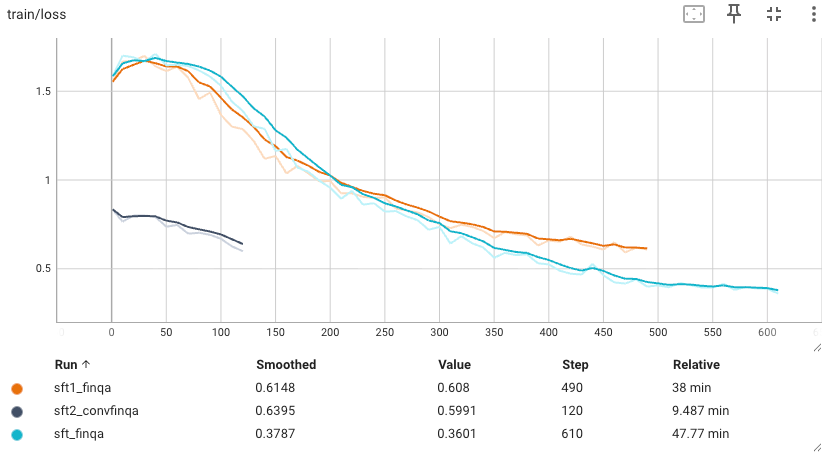

#### v1 & v2: sft1 & sft2
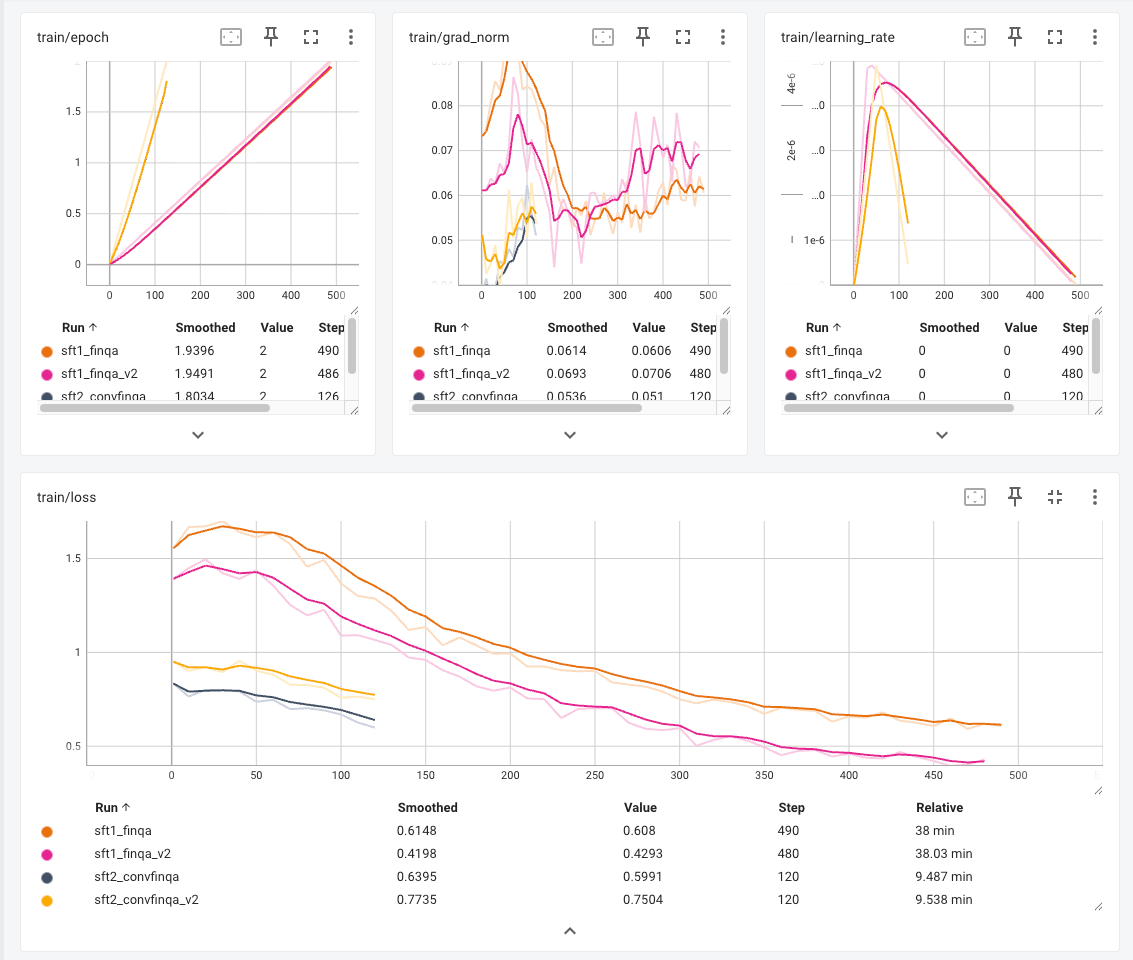

可以见得数据处理更新v2版本后sft1（sft1_finqa_v2）loss下降效果显著

#### v1 & v2: sft
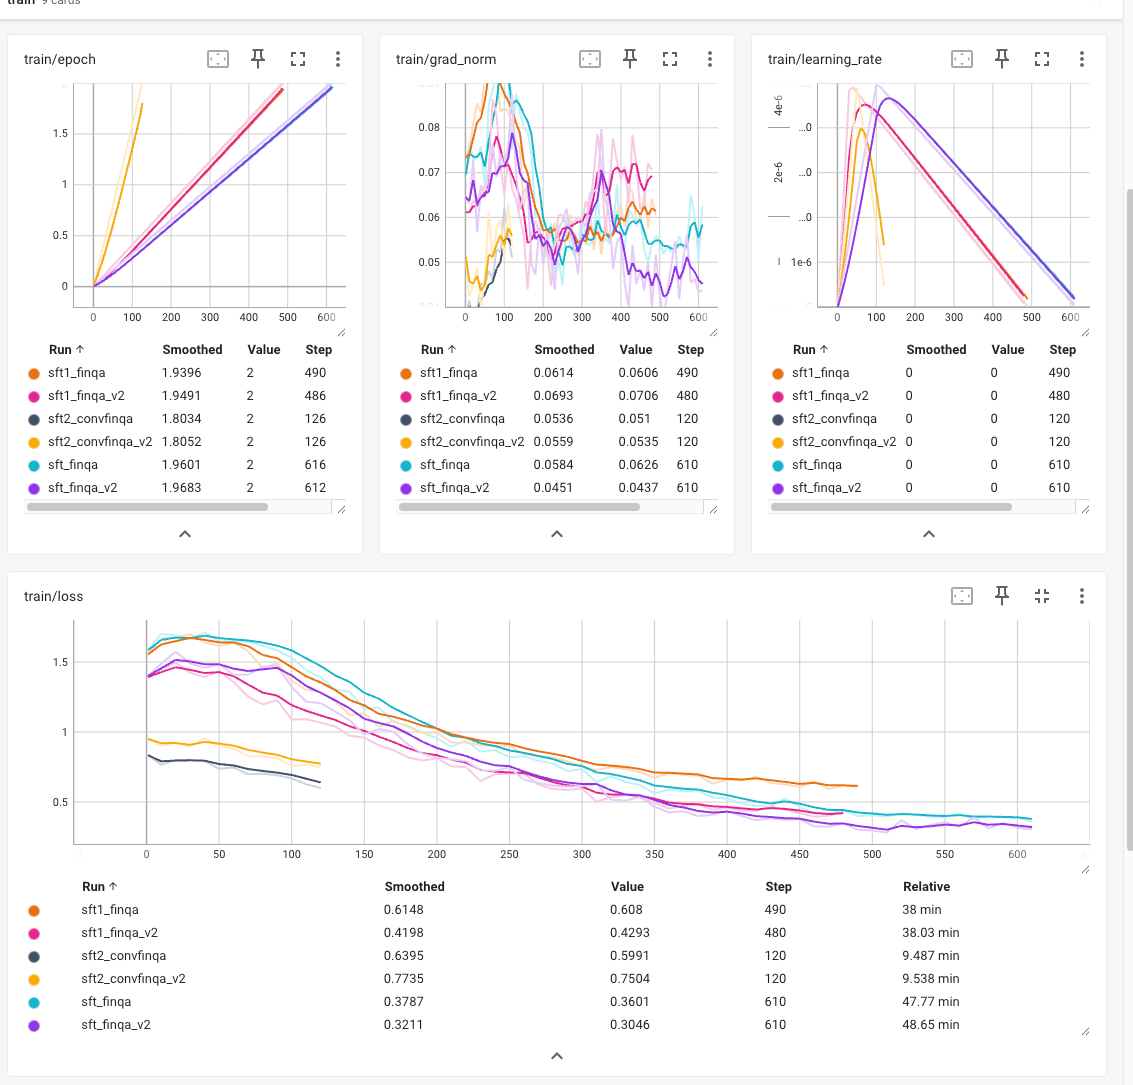
 - v2 在 FinQA（SFT-1）和整体训练上是“真实提升（generalization improvement）”，不是 overfit 假象；但在 ConvFinQA 上，v2 变难了，短期 eval loss 变高是合理现象。
 - 对阶段一（finqa）的提升更为明显，对阶段二（ConvfinQA）效果不那么显著，说明多轮对话的数据集作为微调训练集学习起来更加困难，需要蒸馏。

第一，监督目标更“像人类任务”

模型不再需要学会“奇怪结构转写”，而是学：

题目在问什么;
哪些证据 relevant;
怎么算;
最后答案是什么;

这和你最终评测任务是同构的。

第二，token 难度降低，但任务难度没有降低

这是很多人最容易误判的地方。

loss 变低 ≠ 任务变简单 ≠ 模型偷懒。

你这里更准确地说是：

你降低的是“无意义 token 拟合难度”，不是“金融推理难度”。

也就是说，模型少花力气去背格式，多花力气去学 reasoning path。

第三，训练梯度更一致

当输出格式统一后，模型每次更新看到的是更一致的 supervision schema：

问题分析;
关键证据;
推理程序;
最终答案;

这会让 loss 曲线更平滑、收敛更快、不同 batch 之间冲突更小。


`/root/autodl-tmp/data/financial_reasoning/clean/sft_dir_strict`目录下是
 - `autodl-tmp/data/financial_reasoning/clean/sft_dir_strict/train_sft1_clean_strict.jsonl`
 - `autodl-tmp/data/financial_reasoning/clean/sft_dir_strict/train_sft2_clean_strict.jsonl`

注意训练的时候同一个数据集不要聚集在一起 需要打乱（`supervised_pretrainning`）

In [ ]:
!python -m training.supervised_finetuning --model_name_or_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct --tokenizer_name_or_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct \
    --train_file_dir /root/autodl-tmp/data/financial_reasoning/clean/sft_dir_strict \
    --validation_split_percentage 1 --do_eval --eval_steps 100 --eval_strategy steps \
    --per_device_eval_batch_size 1 --prediction_loss_only True --eval_accumulation_steps 1 --max_eval_samples 32 \
    --do_train --use_peft --num_train_epochs 2 --per_device_train_batch_size 1 --max_grad_norm 1.0 --gradient_accumulation_steps 16 --gradient_checkpointing True \
    --warmup_steps 100 --weight_decay 0.05 --learning_rate 5e-6 \
    --logging_steps 10 --save_steps 200 --logging_first_step True --report_to tensorboard \
    --logging_dir /root/autodl-tmp/outputs/financial_reasoning/tensorboard/sft_finqa_v2 \
    --model_max_length 1024 --target_modules q_proj,k_proj,v_proj,o_proj \
    --lora_rank 8 --lora_alpha 16 --lora_dropout 0.05 \
    --torch_dtype bfloat16 \
    --device_map auto \
    --output_dir /root/autodl-tmp/outputs/financial_reasoning/sft_lora \
    --template_name qwen

当前不能再下“联合训练优于分阶段训练”的结论。

在新的 benchmark 结果下，更重要的是先确认 **SFT v2 数据重建后是否能让 `sft_merged` 不再低于 `base`**。
如果新的 SFT 版本仍弱于 `base`，就不应该继续叠加 DPO 或 GRPO。


In [26]:
SFT_OUT = "/root/autodl-tmp/outputs/financial_reasoning/sft_lora"
SFT_MERGED_OUT = "/root/autodl-tmp/outputs/financial_reasoning/sft_merged"

In [24]:
!python -m tooling.merge_peft_adapter --base_model /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct \
    --tokenizer_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct \
    --lora_model /root/autodl-tmp/outputs/financial_reasoning/sft_lora \
    --output_dir /root/autodl-tmp/outputs/financial_reasoning/sft_merged

Namespace(base_model='/root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct', tokenizer_path='/root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct', lora_model='/root/autodl-tmp/outputs/financial_reasoning/sft_lora', resize_emb=False, output_dir='/root/autodl-tmp/outputs/financial_reasoning/sft_merged', hf_hub_model_id='', hf_hub_token=None)
Base model: /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct
LoRA model: /root/autodl-tmp/outputs/financial_reasoning/sft_lora
Loading LoRA for causal language model
Loading weights: 100%|████████████████████████| 339/339 [00:03<00:00, 98.02it/s]
Merging with merge_and_unload...
Saving to Hugging Face format...
Writing model shards: 100%|███████████████████████| 2/2 [00:31<00:00, 15.52s/it]
Done! model saved to /root/autodl-tmp/outputs/financial_reasoning/sft_merged


### 当前判断

旧版 SFT （sft_v1）结论不能直接沿用。
 - 根据最新 benchmark，`sft_merged` 在 `base` 之下，说明之前的联合训练结论更多反映了训练 loss，而不是最终推理效果。

当前更合理的流程是：重新训练 `sft1 / sft2 / joint sft`；用 `FinQA / ConvFinQA` benchmark 决定是否继续 DPO / GRPO


### benchmark评估

In [27]:
QUICK_BENCHMARK_DIR = OUTPUT_ROOT / "benchmark_quick_sft"
QUICK_CONVFINQA_MAX_SAMPLES = 16
QUICK_FINQA_MAX_SAMPLES = 16
QUICK_MAX_NEW_TOKENS = 1024

CONVFINQA_EVAL_FILE = DATA_DIR / "raw/convfinqa_turn/dev_turn.json"
FINQA_EVAL_FILE = DATA_DIR / "raw/finqa/dev.json"

print(f"ConvFinQA eval file: {CONVFINQA_EVAL_FILE}")
print(f"FinQA eval file: {FINQA_EVAL_FILE}")
print(f"Quick eval samples: convfinqa={QUICK_CONVFINQA_MAX_SAMPLES}, finqa={QUICK_FINQA_MAX_SAMPLES}")
print(f"Quick eval max_new_tokens: {QUICK_MAX_NEW_TOKENS}")
print("Quick eval loading mode: 4-bit")
print("Quick eval default comparison: base vs sft_v2")

quick_benchmark_cmd = [
    'python', 'evaluate_financial_benchmarks.py',
    '--tokenizer_path', BASE_MODEL,
    '--model_entry', f'base={BASE_MODEL}',
    '--model_entry', f'sft={SFT_MERGED_OUT}',
    '--convfinqa_test_file', str(CONVFINQA_EVAL_FILE),
    '--convfinqa_max_samples', str(QUICK_CONVFINQA_MAX_SAMPLES),
    '--finqa_test_file', str(FINQA_EVAL_FILE),
    '--finqa_max_samples', str(QUICK_FINQA_MAX_SAMPLES),
    '--max_new_tokens', str(QUICK_MAX_NEW_TOKENS),
    '--temperature', '0.0',
    '--load_in_4bit',
    '--output_dir', str(QUICK_BENCHMARK_DIR),
]
import shlex
print(' '.join(shlex.quote(part) for part in quick_benchmark_cmd))
subprocess.run(quick_benchmark_cmd, check=True)


ConvFinQA eval file: /root/autodl-tmp/data/financial_reasoning/raw/convfinqa_turn/dev_turn.json
FinQA eval file: /root/autodl-tmp/data/financial_reasoning/raw/finqa/dev.json
Quick eval samples: convfinqa=16, finqa=16
Quick eval max_new_tokens: 1024
Quick eval loading mode: 4-bit
Quick eval default comparison: base vs sft_v2
python -m evaluation.evaluate_financial_benchmarks --tokenizer_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct --model_entry base=/root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct --model_entry sft=/root/autodl-tmp/outputs/financial_reasoning/sft_merged --convfinqa_test_file /root/autodl-tmp/data/financial_reasoning/raw/convfinqa_turn/dev_turn.json --convfinqa_max_samples 16 --finqa_test_file /root/autodl-tmp/data/financial_reasoning/raw/finqa/dev.json --finqa_max_samples 16 --max_new_tokens 1024 --temperature 0.0 --load_in_4bit --output_dir /root/autodl-tmp/outputs/financial_reasoning/benchmark_quick_sft
[prep] convfinqa_turn: dedup dropped 1072 rows befor

Evaluating base:   0%|          | 0/32 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
/root/miniconda3/envs/llm/lib/python3.10/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Evaluating base: 100%|██████████| 32/32 [05:22<00:00, 10.08s/it]


[eval] model=sft path=/root/autodl-tmp/outputs/financial_reasoning/sft_merged adapter=none


Evaluating sft: 100%|██████████| 32/32 [04:26<00:00,  8.33s/it]


[done] Saved benchmark outputs to: /root/autodl-tmp/outputs/financial_reasoning/benchmark_quick_sft


CompletedProcess(args=['python', 'evaluate_financial_benchmarks.py', '--tokenizer_path', '/root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct', '--model_entry', 'base=/root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct', '--model_entry', 'sft=/root/autodl-tmp/outputs/financial_reasoning/sft_merged', '--convfinqa_test_file', '/root/autodl-tmp/data/financial_reasoning/raw/convfinqa_turn/dev_turn.json', '--convfinqa_max_samples', '16', '--finqa_test_file', '/root/autodl-tmp/data/financial_reasoning/raw/finqa/dev.json', '--finqa_max_samples', '16', '--max_new_tokens', '1024', '--temperature', '0.0', '--load_in_4bit', '--output_dir', '/root/autodl-tmp/outputs/financial_reasoning/benchmark_quick_sft'], returncode=0)

In [28]:

summary_csv = QUICK_BENCHMARK_DIR / 'benchmark_summary.csv'
summary_json = QUICK_BENCHMARK_DIR / 'benchmark_summary.json'
if summary_csv.exists():
    summary_df = pd.read_csv(summary_csv)
    display(summary_df)
    focus_cols = [
        'model_name', 'task_name', 'answer_accuracy', 'program_accuracy',
        'numeric_parse_rate', 'final_answer_coverage',
        'program_section_coverage', 'structured_response_coverage',
        'avg_prediction_chars'
    ]
    display(summary_df[[c for c in focus_cols if c in summary_df.columns]])
elif summary_json.exists():
    display(pd.DataFrame(json.loads(summary_json.read_text(encoding='utf-8'))))

,model_name,task_name,num_examples,answer_accuracy,primary_metric,program_accuracy,final_answer_coverage,program_section_coverage,structured_response_coverage,numeric_parse_rate,avg_prediction_chars
0,base,convfinqa_test,16,0.3125,0.3125,0.00000,1.0000,1.00000,1.0000,1.00000,479.50000
1,base,finqa_test,16,0.3125,0.3125,0.00000,1.0000,1.00000,1.0000,0.93750,433.81250
2,base,bucket_convfinqa,16,0.3125,0.3125,0.00000,1.0000,1.00000,1.0000,1.00000,479.50000
3,base,bucket_finqa,16,0.3125,0.3125,0.00000,1.0000,1.00000,1.0000,0.93750,433.81250
4,base,macro_average,32,0.3125,0.3125,0.00000,1.0000,1.00000,1.0000,0.96875,456.65625
5,sft,convfinqa_test,16,0.0000,0.0000,0.00000,0.9375,1.00000,0.9375,1.00000,540.06250
6,sft,finqa_test,16,0.2500,0.2500,0.06250,0.9375,0.93750,0.9375,0.93750,637.37500
7,sft,bucket_convfinqa,16,0.0000,0.0000,0.00000,0.9375,1.00000,0.9375,1.00000,540.06250
8,sft,bucket_finqa,16,0.2500,0.2500,0.06250,0.9375,0.93750,0.9375,0.93750,637.37500
9,sft,macro_average,32,0.1250,0.1250,0.03125,0.9375,0.96875,0.9375,0.96875,588.71875


,model_name,task_name,answer_accuracy,program_accuracy,numeric_parse_rate,final_answer_coverage,program_section_coverage,structured_response_coverage,avg_prediction_chars
0,base,convfinqa_test,0.3125,0.00000,1.00000,1.0000,1.00000,1.0000,479.50000
1,base,finqa_test,0.3125,0.00000,0.93750,1.0000,1.00000,1.0000,433.81250
2,base,bucket_convfinqa,0.3125,0.00000,1.00000,1.0000,1.00000,1.0000,479.50000
3,base,bucket_finqa,0.3125,0.00000,0.93750,1.0000,1.00000,1.0000,433.81250
4,base,macro_average,0.3125,0.00000,0.96875,1.0000,1.00000,1.0000,456.65625
5,sft,convfinqa_test,0.0000,0.00000,1.00000,0.9375,1.00000,0.9375,540.06250
6,sft,finqa_test,0.2500,0.06250,0.93750,0.9375,0.93750,0.9375,637.37500
7,sft,bucket_convfinqa,0.0000,0.00000,1.00000,0.9375,1.00000,0.9375,540.06250
8,sft,bucket_finqa,0.2500,0.06250,0.93750,0.9375,0.93750,0.9375,637.37500
9,sft,macro_average,0.1250,0.03125,0.96875,0.9375,0.96875,0.9375,588.71875


参考v1benchmark(`autodl-tmp/outputs/financial_reasoning/benchmark_quick`),v2benchmark(`autodl-tmp/outputs/financial_reasoning/benchmark_quick_sft`)蒸馏是当务之急。

## DPO

轻量 DPO 目标：
- 优化表达质量
- 保持结构完整
- 减少废话
- 不让偏好训练覆盖主干 reasoning 能力


In [4]:
all_specs = SFT1_DATA_SPECS + SFT2_DATA_SPECS
total_source_target = sum(spec['target_rows'] for spec in all_specs if spec['target_rows'] > 0)

mixed_rows = []
dpo_mix_report = []

for spec in all_specs:
    path = DPO_DIR / f"{spec['name']}_dpo.jsonl"
    source_rows, source_report, source_bad_chunks = read_jsonl_objects(path)
    if source_bad_chunks:
        raise ValueError(f"Invalid DPO source JSONL: {path} -> {source_bad_chunks[0]}")

    if total_source_target > 0:
        proportional_target = int(round(DPO_TOTAL_BUDGET * spec['target_rows'] / total_source_target))
    else:
        proportional_target = 0

    dpo_target = min(MAX_DPO_PER_DATASET, spec.get('max_rows') or 10**9, proportional_target)
    sampled_rows = sample_records(source_rows, dpo_target, seed=RANDOM_SEED)
    mixed_rows.extend(sampled_rows)
    dpo_mix_report.append({
        'source_dataset': spec['name'],
        'source_rows': len(source_rows),
        'target_rows': dpo_target,
        'sampled_rows': len(sampled_rows),
        'literal_separator_count': source_report['literal_separator_count'],
    })

write_jsonl_objects(DPO_MIXED_FILE, mixed_rows)
normalized_rows, normalized_report, normalized_bad_chunks = read_jsonl_objects(DPO_MIXED_FILE)
if normalized_bad_chunks:
    raise ValueError(f"Invalid mixed DPO JSONL after rewrite: {normalized_bad_chunks[0]}")

write_jsonl_objects(DPO_TRAIN_DIR / DPO_MIXED_FILE.name, normalized_rows)

print('[DPO mix normalization report]')
print(json.dumps({
    'mixed_rows': len(normalized_rows),
    'literal_separator_count_in_mixed_file': normalized_report['literal_separator_count'],
    'sources': dpo_mix_report,
}, ensure_ascii=False, indent=2))



[DPO mix normalization report]
{
  "mixed_rows": 3879,
  "literal_separator_count_in_mixed_file": 0,
  "sources": [
    {
      "source_dataset": "finqa_train",
      "source_rows": 6203,
      "target_rows": 1879,
      "sampled_rows": 1879,
      "literal_separator_count": 0
    },
    {
      "source_dataset": "fingpt_convfinqa_train",
      "source_rows": 2096,
      "target_rows": 2000,
      "sampled_rows": 2000,
      "literal_separator_count": 0
    }
  ]
}


In [7]:
merge_sft_cmd = [
    'python', 'merge_peft_adapter.py',
    '--base_model', BASE_MODEL,
    '--tokenizer_path', BASE_MODEL,
    '--lora_model', str(SFT_OUT),
    '--output_dir', str(SFT_MERGED_OUT),
]
print(' '.join(merge_sft_cmd))
# subprocess.run(merge_sft_cmd, check=True)


python -m tooling.merge_peft_adapter --base_model /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct --tokenizer_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct --lora_model /root/autodl-tmp/outputs/financial_reasoning/sft_lora --output_dir /root/autodl-tmp/outputs/financial_reasoning/sft_merged


### DPO 质量统计展示（训练前）

在执行 `dpo_training.py` 前，先检查 DPO 数据质量：
- 规模与去重
- 结构锚点覆盖（如 `最终答案：/推理程序：`）
- `source_dataset` 分布
- 抽样查看 `chosen/rejected`


In [6]:
from pathlib import Path
import json
import pandas as pd

rows, dpo_read_report, dpo_bad_chunks = read_jsonl_objects(DPO_MIXED_FILE)
if dpo_bad_chunks:
    raise ValueError(f'Invalid DPO jsonl: {DPO_MIXED_FILE} -> {dpo_bad_chunks[0]}')
if not rows:
    raise ValueError(f'No DPO rows found: {DPO_MIXED_FILE}')

print('[DPO jsonl validation report]')
print(json.dumps(dpo_read_report, ensure_ascii=False, indent=2))

anchors = ['最终答案：', '推理程序：', '结论：', '推理：', '解释：']

def _has_anchor(text: str) -> bool:
    return any(a in (text or '') for a in anchors)

triplets = [
    (r.get('question', ''), r.get('response_chosen', ''), r.get('response_rejected', ''))
    for r in rows
]
unique_triplets = len(set(triplets))

quality_summary = pd.DataFrame([
    {'metric': 'total_rows', 'value': len(rows)},
    {'metric': 'unique_triplets', 'value': unique_triplets},
    {'metric': 'duplicate_triplets', 'value': len(rows) - unique_triplets},
    {'metric': 'empty_question_rows', 'value': sum(1 for r in rows if not str(r.get('question', '')).strip())},
    {'metric': 'empty_chosen_rows', 'value': sum(1 for r in rows if not str(r.get('response_chosen', '')).strip())},
    {'metric': 'empty_rejected_rows', 'value': sum(1 for r in rows if not str(r.get('response_rejected', '')).strip())},
    {'metric': 'chosen_anchor_covered_rows', 'value': sum(1 for r in rows if _has_anchor(r.get('response_chosen', '')))},
    {'metric': 'rejected_anchor_covered_rows', 'value': sum(1 for r in rows if _has_anchor(r.get('response_rejected', '')))},
])

length_df = pd.DataFrame({
    'question_chars': [len(str(r.get('question', ''))) for r in rows],
    'chosen_chars': [len(str(r.get('response_chosen', ''))) for r in rows],
    'rejected_chars': [len(str(r.get('response_rejected', ''))) for r in rows],
}).describe().T[['count', 'mean', '50%', 'max']].reset_index().rename(columns={'index': 'field'})

source_dist_df = (
    pd.DataFrame({'source_dataset': [r.get('source_dataset', '') for r in rows]})
    .value_counts()
    .reset_index(name='rows')
)

preview_rows = []
for r in rows[:8]:
    preview_rows.append({
        'source_dataset': r.get('source_dataset', ''),
        'record_id': r.get('record_id', ''),
        'question_preview': str(r.get('question', ''))[:120],
        'chosen_preview': str(r.get('response_chosen', ''))[:120],
        'rejected_preview': str(r.get('response_rejected', ''))[:120],
    })
preview_df = pd.DataFrame(preview_rows)

print('[DPO quality summary]')
display(quality_summary)
print('\n[Length statistics]')
display(length_df)
print('\n[Source dataset distribution]')
display(source_dist_df)
print('\n[DPO sample preview]')
display(preview_df)



[DPO jsonl validation report]
{
  "path": "/root/autodl-tmp/data/financial_reasoning/dpo_pairs/train_reasoning_dpo.jsonl",
  "rows": 3879,
  "bad_chunks": 0,
  "literal_separator_count": 0
}
[DPO quality summary]


,metric,value
0,total_rows,3879
1,unique_triplets,3879
2,duplicate_triplets,0
3,empty_question_rows,0
4,empty_chosen_rows,0
5,empty_rejected_rows,0
6,chosen_anchor_covered_rows,3879
7,rejected_anchor_covered_rows,3879



[Length statistics]


,field,count,mean,50%,max
0,question_chars,3879.0,2198.796597,2183.0,4600.0
1,chosen_chars,3879.0,355.922403,343.0,589.0
2,rejected_chars,3879.0,326.453467,315.0,527.0



[Source dataset distribution]


,source_dataset,rows
0,ConvFinQA,2000
1,FinQA,1879



[DPO sample preview]


,source_dataset,record_id,question_preview,chosen_preview,rejected_preview
0,FinQA,ADI/2009/page_49.pdf-1,你是一名金融表文混合推理助手。请结合文本、表格和问题，给出可执行的推理程序与最终答案。\n\...,问题分析：需要从财报文本和表格中定位相关指标，并依据程序完成数值计算。\n关键证据：\n- ...,问题分析：需要从财报文本和表格中定位相关指标，并依据程序完成数值计算。\n关键证据：\n- ...
1,FinQA,ABMD/2012/page_75.pdf-1,你是一名金融表文混合推理助手。请结合文本、表格和问题，给出可执行的推理程序与最终答案。\n\...,问题分析：需要从财报文本和表格中定位相关指标，并依据程序完成数值计算。\n关键证据：\n- ...,问题分析：需要从财报文本和表格中定位相关指标，并依据程序完成数值计算。\n关键证据：\n- ...
2,FinQA,AMT/2012/page_121.pdf-1,你是一名金融表文混合推理助手。请结合文本、表格和问题，给出可执行的推理程序与最终答案。\n\...,问题分析：需要从财报文本和表格中定位相关指标，并依据程序完成数值计算。\n关键证据：\n- ...,问题分析：需要从财报文本和表格中定位相关指标，并依据程序完成数值计算。\n关键证据：\n- ...
3,FinQA,IPG/2009/page_89.pdf-3,你是一名金融表文混合推理助手。请结合文本、表格和问题，给出可执行的推理程序与最终答案。\n\...,问题分析：需要从财报文本和表格中定位相关指标，并依据程序完成数值计算。\n关键证据：\n- ...,问题分析：需要从财报文本和表格中定位相关指标，并依据程序完成数值计算。\n关键证据：\n- ...
4,FinQA,PNC/2012/page_110.pdf-3,你是一名金融表文混合推理助手。请结合文本、表格和问题，给出可执行的推理程序与最终答案。\n\...,问题分析：需要从财报文本和表格中定位相关指标，并依据程序完成数值计算。\n关键证据：\n- ...,问题分析：需要从财报文本和表格中定位相关指标，并依据程序完成数值计算。\n关键证据：\n- ...
5,FinQA,SWKS/2011/page_82.pdf-1,你是一名金融表文混合推理助手。请结合文本、表格和问题，给出可执行的推理程序与最终答案。\n\...,问题分析：需要从财报文本和表格中定位相关指标，并依据程序完成数值计算。\n关键证据：\n- ...,问题分析：需要从财报文本和表格中定位相关指标，并依据程序完成数值计算。\n关键证据：\n- ...
6,FinQA,INTC/2013/page_71.pdf-2,你是一名金融表文混合推理助手。请结合文本、表格和问题，给出可执行的推理程序与最终答案。\n\...,问题分析：需要从财报文本和表格中定位相关指标，并依据程序完成数值计算。\n关键证据：\n- ...,问题分析：需要从财报文本和表格中定位相关指标，并依据程序完成数值计算。\n关键证据：\n- ...
7,FinQA,JPM/2010/page_144.pdf-2,你是一名金融表文混合推理助手。请结合文本、表格和问题，给出可执行的推理程序与最终答案。\n\...,问题分析：需要从财报文本和表格中定位相关指标，并依据程序完成数值计算。\n关键证据：\n- ...,问题分析：需要从财报文本和表格中定位相关指标，并依据程序完成数值计算。\n关键证据：\n- ...


In [ ]:
dpo_cmd = [
    'python', 'dpo_training.py',
    '--model_name_or_path', str(SFT_MERGED_OUT),
    '--tokenizer_name_or_path', BASE_MODEL,
    '--template_name', TEMPLATE_NAME,
    '--train_file_dir', str(DPO_TRAIN_DIR),
    '--validation_split_percentage', '1',
    '--do_train',
    '--use_peft', 'True',
    '--per_device_train_batch_size', '1',
    '--gradient_accumulation_steps', '16',
    '--gradient_checkpointing', 'True',
    '--learning_rate', '5e-7',
    '--max_steps', '200',
    '--max_source_length', '1024',
    '--max_target_length', '512',
    '--logging_steps', '10',
    '--save_steps', '200',
    '--target_modules', 'all',
    '--lora_rank', '8',
    '--lora_alpha', '16',
    '--lora_dropout', '0.05',
    '--torch_dtype', 'float16',
    '--device_map', 'auto',
    '--output_dir', str(DPO_OUT),
]
print(' '.join(dpo_cmd))
# subprocess.run(dpo_cmd, check=True)


python -m training.dpo_training --model_name_or_path /root/autodl-tmp/outputs/financial_reasoning/sft2_merged --tokenizer_name_or_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct --template_name qwen --train_file_dir /root/autodl-tmp/data/financial_reasoning/dpo_pairs/train_dir --validation_split_percentage 1 --do_train --use_peft True --per_device_train_batch_size 1 --gradient_accumulation_steps 16 --gradient_checkpointing True --learning_rate 5e-7 --max_steps 200 --max_source_length 1024 --max_target_length 512 --logging_steps 10 --save_steps 200 --target_modules all --lora_rank 8 --lora_alpha 16 --lora_dropout 0.05 --torch_dtype float16 --device_map auto --output_dir /root/autodl-tmp/outputs/financial_reasoning/dpo_lora


In [ ]:
!python -m training.dpo_training --model_name_or_path /root/autodl-tmp/outputs/financial_reasoning/sft_merged \
--tokenizer_name_or_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct \
--template_name qwen \
--validation_split_percentage 1 --eval_strategy no \
--train_file_dir /root/autodl-tmp/data/financial_reasoning/dpo_pairs/train_dir \
--do_train --use_peft True \
--per_device_train_batch_size 1 --gradient_accumulation_steps 16 --gradient_checkpointing True \
--learning_rate 5e-6 --max_steps 200 --max_source_length 512 --max_target_length 256 \
--logging_steps 10 --save_steps 40  --logging_first_step True \
--target_modules q_proj,k_proj,v_proj,o_proj \
--lora_rank 8 --lora_alpha 16 --lora_dropout 0.05 \
--torch_dtype bfloat16 --device_map auto \
--ddp_find_unused_parameters False \
--output_dir /root/autodl-tmp/outputs/financial_reasoning/dpo_lora

1. 模型有没有学会“偏好 chosen > rejected”
2. 这种偏好学习是健康推进，还是过拟合/塌缩
3. 训练是否已经到该停的时候


最基础的是**判断训练有没有真正发生作用**。

这主要看 `train/loss` 和 `train/rewards/accuracies`：loss 是否持续下降、reward accuracy 是否从较低水平逐步上升。
- 如果这两个指标没有明显变化，说明模型几乎没有学到偏好；而如果 loss 快速下降、accuracy 很快接近 1，则说明模型已经很好地拟合了训练集中的 chosen/rejected 偏好关系，但这时反而需要警惕过拟合，因为 DPO 的目标是泛化偏好，而不是在训练集上“记住答案”。

在确认训练有效之后，第二步要关注模型到底 **“学了什么”** 。

这需要结合 `logps/chosen` 和 `logps/rejected` 来看。
- 理想情况是：模型对 chosen 的概率提高（logps 变得不那么负），同时对 rejected 的概率降低，这意味着模型既在强化正确回答，也在抑制错误回答。
- 但在很多实际训练中（包括你现在的曲线），后期往往表现为 chosen 基本不变，而 rejected 急剧下降，这说明模型主要是在“打压 rejected”，而不是进一步提升正向推理能力。
- 这种现象在对齐阶段非常常见，但对金融数值推理任务来说可能带来风险——模型更像是在模仿 preferred 模板，而不是更好地进行计算和推理。

第三步则是判断训练是否进入 **“过度优化”或“偏好饱和”** 阶段。

这主要依赖 `entropy`、`grad_norm` 和 `reward accuracy` 的联合判断：
1. 当 entropy 持续下降，说明模型输出分布越来越确定、越来越“自信”；
2. grad_norm 明显衰减，说明每一步参数更新的有效信息越来越少'；
3. reward accuracy 已接近 1。

这三者同时出现时，通常意味着模型已经把训练集偏好学完，后续训练收益极小，甚至可能开始损害泛化能力。
- 这也是为什么 DPO 训练往往需要“早停”，而不能单纯依赖 loss 最低来选择模型。

除此之外，还有一些辅助指标帮助你更细致理解训练过程。
- 例如 `mean_token_accuracy` 可以反映模型逐 token 的预测能力，但在 DPO 中它并不是核心指标，因为 DPO 优化的是排序而不是逐 token 拟合；
- `learning_rate` 帮助你解释 loss 或 grad_norm 的变化是否来自学习率调度；
- `epoch` 和 `num_tokens` 则用于判断数据是否被反复使用过多，从而导致过拟合风险。这些指标本身不直接决定模型好坏，但在解释训练行为时非常关键。

总结来说，DPO 曲线的分析核心不是“哪个指标更高或更低”，而是看这些指标之间是否形成一致的逻辑：是否有效学习了偏好、这种学习是正向增强还是负向打压、以及是否已经进入饱和甚至过拟合阶段。最终，任何训练曲线的结论都必须通过下游金融推理 benchmark 来验证，而不能仅凭训练指标判断模型优劣。


| 指标                       | 含义                        | 健康趋势    | 危险信号       | 主要作用       |
| ------------------------ | ------------------------- | ------- | ---------- | ---------- |
| train/loss               | 偏好优化目标（chosen > rejected） | 持续下降后趋稳 | 快速降到极低     | 判断训练是否有效   |
| rewards/accuracies       | chosen 是否优于 rejected 的比例  | 上升并接近高值 | 很快达到 1 并稳定 | 判断偏好是否已学满  |
| logps/chosen             | 对正确回答的概率                  | 逐渐上升    | 基本不变       | 判断正向增强     |
| logps/rejected           | 对错误回答的概率                  | 逐渐下降    | 过度下降       | 判断负向打压     |
| logits/chosen / rejected | 原始打分                      | 两者差距拉大  | 波动异常       | 辅助验证偏好分离   |
| entropy                  | 输出分布不确定性                  | 缓慢下降    | 持续大幅下降     | 判断模型是否变“僵” |
| grad_norm                | 参数更新幅度                    | 逐渐下降    | 过快衰减或爆炸    | 判断是否收敛或不稳定 |
| mean_token_accuracy      | token级预测准确率               | 稳定或略升   | 明显下降或无变化   | 判断是否提升生成能力 |
| learning_rate            | 学习率变化                     | 按计划变化   | 异常波动       | 辅助解释训练变化   |
| epoch                    | 数据遍历次数                    | 平稳增加    | 过高         | 判断是否重复训练过多 |
| num_tokens               | 累计训练token数                | 线性增长    | 无明显异常      | 衡量训练规模     |


> **DPO 的理想状态是：loss 下降、reward accuracy 提升、chosen 上升 + rejected 下降，同时 entropy 和 grad_norm 平稳衰减；一旦 reward accuracy≈1 且 entropy/grad_norm 同时塌缩，就需要考虑早停并转向 benchmark 验证。**


rewards/accuracies = 1 连续出现，说明这段训练已经变得“很容易”。
这不一定是坏事，但要警惕两种情况：

一种是好现象：
你的 DPO pairs 质量不错，模型确实快速学会了区分好坏。

另一种是风险信号：
你的 pair 可能偏简单，或者数据量偏小，模型很快把训练集偏好“吃透”了。
如果继续训下去，可能出现：

训练 reward 继续飙升；
但泛化不再提升；
甚至对输出风格造成过强偏置

所以你现在最该关注的，不再是“有没有学起来”，而是有没有开始过拟合偏好数据。

```
***** train metrics *****
  total_flos               = 117019641GF
  train_loss               =      0.3516
  train_runtime            =  0:29:30.07
  train_samples            =        3840
  train_samples_per_second =       1.808
  train_steps_per_second   =       0.113
2026-04-02 23:58:19.725 | DEBUG    | __main__:main:504 - Training metrics: {'train_runtime': 1770.0794, 'train_samples_per_second': 1.808, 'train_steps_per_second': 0.113, 'total_flos': 1.2564888381652992e+17, 'train_loss': 0.35161001563072203, 'train_samples': 3840}
2026-04-02 23:58:19.726 | INFO     | __main__:main:505 - Saving model checkpoint to /root/autodl-tmp/outputs/financial_reasoning/dpo_lora
```
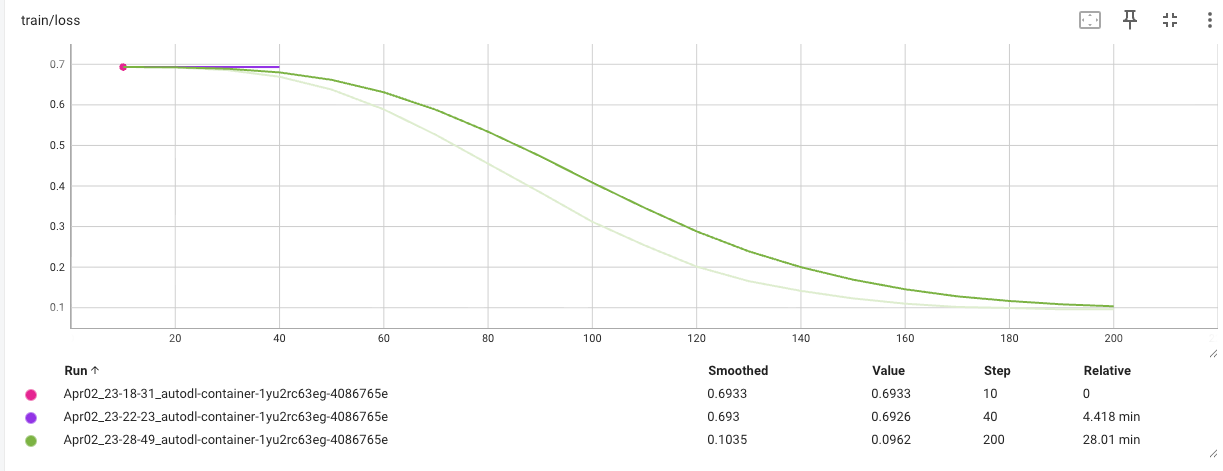

修改数据后的训练

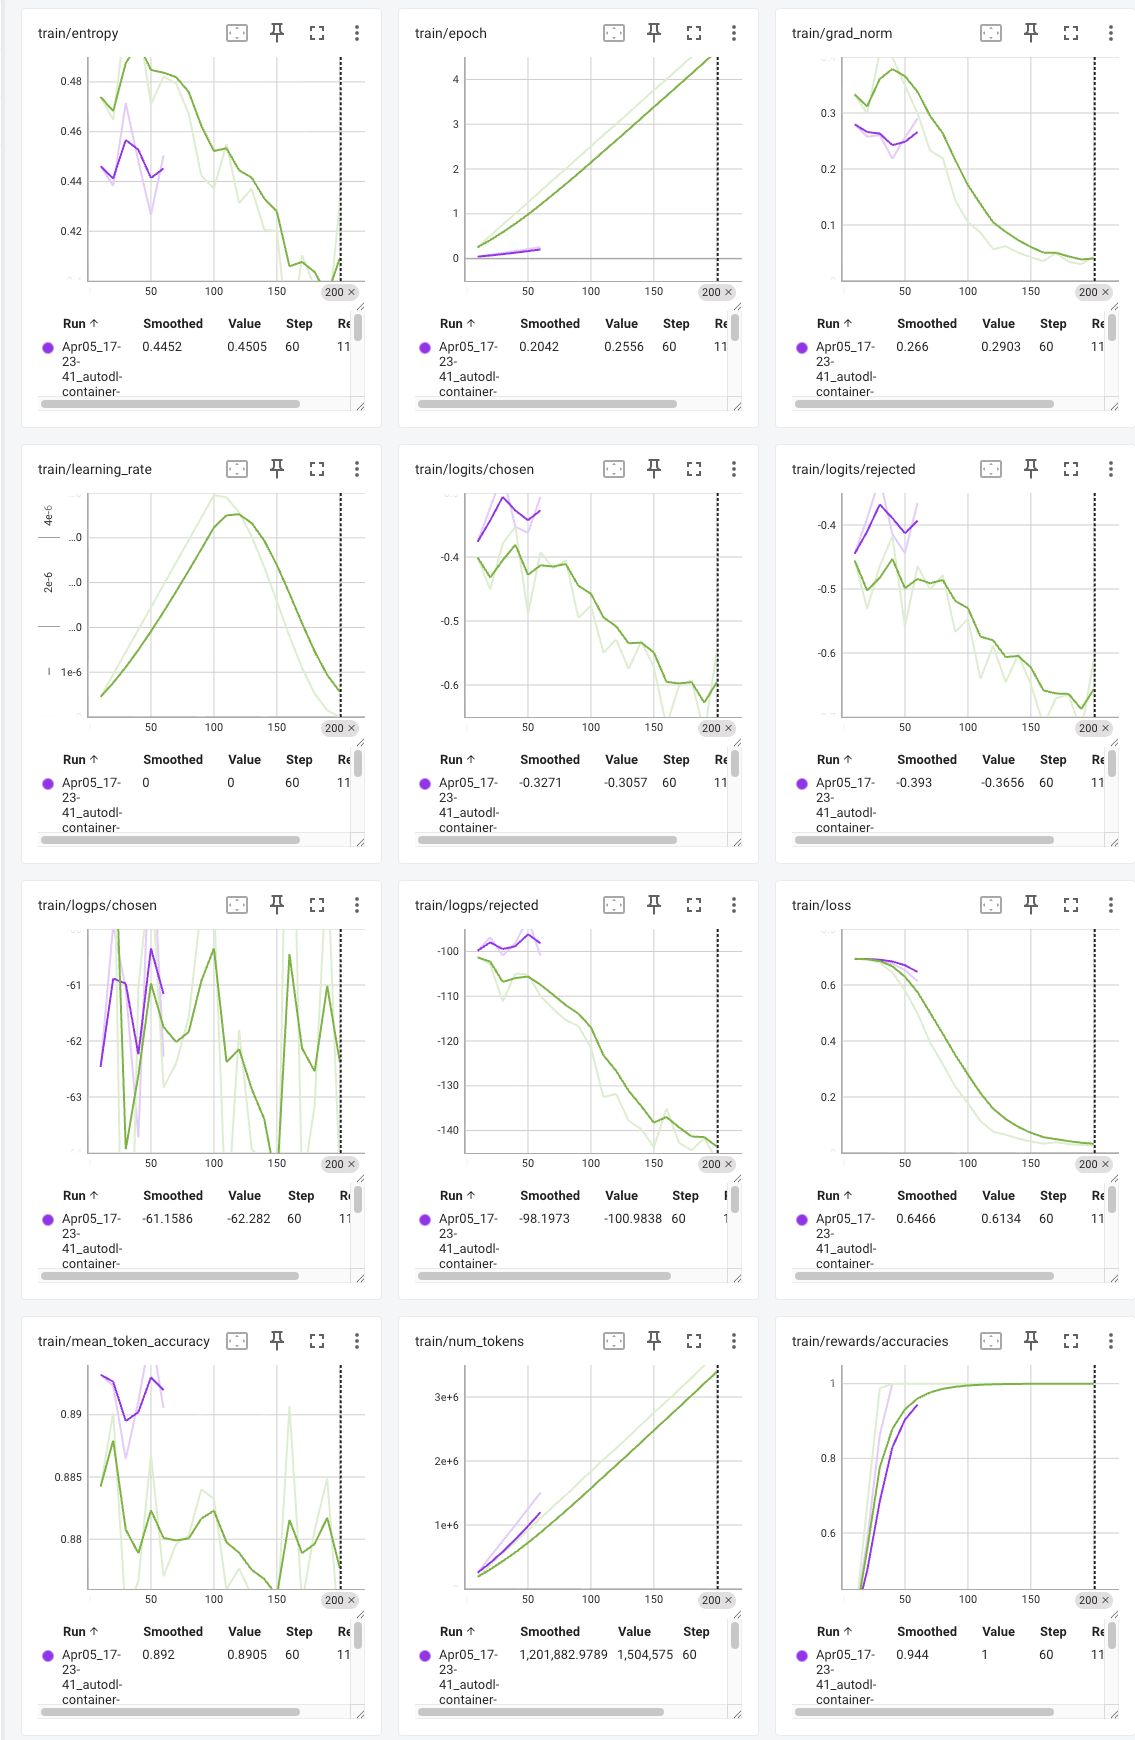

--max_source_length 1024 --max_target_length 512 改成 512 / 256 之后（绿色），训练“更激进、更有效率”，但也更不稳定、更偏向短样本分布；而原来的紫色配置则是更稳、更保守，但优化推进更慢。

这其实已经告诉你一个结论：

512/256 更适合作为“先把 DPO 跑通、先建立偏好能力”的工程配置；
1024/512 更像“保留更完整推理上下文，但训练成本更高”的研究配置。

再结合 train/entropy 看，会更清楚。绿色 entropy 整体比紫色更高一些，且波动幅度也更大。entropy 高不一定坏，它表示输出分布没有那么快塌缩，模型还保留一定探索/不确定性；但在你这组图里，绿色不是“稳定地高”，而是“抖着高”，这更像是：模型在短长度下更新更剧烈，分布变化更频繁。

这和前面 logit / logps 的观察是统一的：绿色优化更猛，但稳定性更差。

再看 train/grad_norm。绿色的 grad norm 基本始终高于紫色，而且中间还有比较明显的抬升。这其实非常关键，因为它说明缩短长度后，虽然显存压力降了，但每一步参数更新“冲击力”反而更大了。很多人会误以为“长度缩短 = 训练更稳定”，其实不一定。长度缩短通常会让：

每 step 更便宜；
loss 更容易下降

但也可能让：

梯度更尖锐；
更容易过拟合当前 pair；
更容易学到“局部偏好模板”

在训练集上 chosen/rejected 区分更好了，但真实测试时对长题干、多轮上下文、表格条件的利用反而下降。


## 评估：SFT vs SFT+DPO

（当前主测 FinQA + ConvFinQA）

按照 `README_fingpt.md` 的 fix 计划，这里比较 `SFT` 和 `DPO`：
- 任务结果：`answer_accuracy`、`program_accuracy`、`numeric_parse_rate`
- 输出质量：`final_answer_coverage`、`program_section_coverage`、`structured_response_coverage`、`avg_prediction_chars`

评测设置：
- `base`：基座模型
- `sft`：`SFT` merge 后模型
- `dpo`：以 `SFT` merge 模型为 base，再挂载 `DPO` LoRA adapter
- `ConvFinQA`：优先 `dev_turn.json`
- `FinQA`：优先 `test.json`，不存在则回退 `dev.json`

### benchmark 快速评估（base vs sft_merged vs sft_merged+dpo）

目标：快速跑出一版可比较结果，而不是追求完整 benchmark。

默认比较三组模型：
- `base`：基座模型
- `sft`：`SFT_MERGED_OUT`
- `dpo`：以 `SFT_MERGED_OUT` 为 base，挂载 `DPO_OUT` adapter

快速评估策略：
- `ConvFinQA` 只抽小样本
- `FinQA` 只抽小样本
- `temperature=0.0`
- `max_new_tokens` 限制为较小值

重点看两类指标：
- 任务结果：`answer_accuracy`、`program_accuracy`、`numeric_parse_rate`
- 输出质量：`final_answer_coverage`、`program_section_coverage`、`structured_response_coverage`



In [ ]:
QUICK_BENCHMARK_DIR = OUTPUT_ROOT / "benchmark_quick"
QUICK_CONVFINQA_MAX_SAMPLES = 16
QUICK_FINQA_MAX_SAMPLES = 16
QUICK_MAX_NEW_TOKENS = 1024

CONVFINQA_EVAL_FILE = DATA_DIR / "raw/convfinqa_turn/dev_turn.json"
FINQA_EVAL_FILE = DATA_DIR / "raw/finqa/dev.json"

print(f"ConvFinQA eval file: {CONVFINQA_EVAL_FILE}")
print(f"FinQA eval file: {FINQA_EVAL_FILE}")
print(f"Quick eval samples: convfinqa={QUICK_CONVFINQA_MAX_SAMPLES}, finqa={QUICK_FINQA_MAX_SAMPLES}")
print(f"Quick eval max_new_tokens: {QUICK_MAX_NEW_TOKENS}")
print("Quick eval loading mode: 4-bit")
print("Quick eval default comparison: sft vs dpo")

quick_benchmark_cmd = [
    'python', 'evaluate_financial_benchmarks.py',
    '--tokenizer_path', BASE_MODEL,
    '--model_entry', f'base={BASE_MODEL}',
    '--model_entry', f'sft={SFT_MERGED_OUT}',
    '--model_entry', f'dpo={SFT_MERGED_OUT}',
    '--adapter_entry', f'dpo={DPO_OUT}',
    '--convfinqa_test_file', str(CONVFINQA_EVAL_FILE),
    '--convfinqa_max_samples', str(QUICK_CONVFINQA_MAX_SAMPLES),
    '--finqa_test_file', str(FINQA_EVAL_FILE),
    '--finqa_max_samples', str(QUICK_FINQA_MAX_SAMPLES),
    '--max_new_tokens', str(QUICK_MAX_NEW_TOKENS),
    '--temperature', '0.0',
    '--load_in_4bit',
    '--output_dir', str(QUICK_BENCHMARK_DIR),
]
print(' '.join(shlex.quote(part) for part in quick_benchmark_cmd))
subprocess.run(quick_benchmark_cmd, check=True)


python -m evaluation.evaluate_financial_benchmarks --tokenizer_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct --model_entry base=/root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct --model_entry sft=/root/autodl-tmp/outputs/financial_reasoning/sft_merged --model_entry dpo=/root/autodl-tmp/outputs/financial_reasoning/sft_merged --adapter_entry dpo=/root/autodl-tmp/outputs/financial_reasoning/dpo_lora --convfinqa_test_file /root/autodl-tmp/data/financial_reasoning/raw/convfinqa_turn/dev_turn.json --convfinqa_max_samples 16 --finqa_test_file /root/autodl-tmp/data/financial_reasoning/raw/finqa/dev.json --finqa_max_samples 16 --max_new_tokens 1024 --temperature 0.0 --load_in_4bit --output_dir /root/autodl-tmp/outputs/financial_reasoning/benchmark_quick


[prep] convfinqa_turn: dedup dropped 1072 rows before evaluation
[prep] convfinqa_turn: skipped 121 rows during benchmark example build
[skip] Fineval disabled (use --run_fineval or set --fineval_local_file to enable).
[eval] model=base path=/root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct adapter=none


Evaluating base:   0%|          | 0/32 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
/root/miniconda3/envs/llm/lib/python3.10/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Evaluating base: 100%|██████████| 32/32 [05:25<00:00, 10.17s/it]


[eval] model=sft path=/root/autodl-tmp/outputs/financial_reasoning/sft_merged adapter=none


Evaluating sft: 100%|██████████| 32/32 [04:02<00:00,  7.57s/it]


[eval] model=dpo path=/root/autodl-tmp/outputs/financial_reasoning/sft_merged adapter=/root/autodl-tmp/outputs/financial_reasoning/dpo_lora


Evaluating dpo: 100%|██████████| 32/32 [05:12<00:00,  9.77s/it]


[done] Saved benchmark outputs to: /root/autodl-tmp/outputs/financial_reasoning/benchmark_quick


CompletedProcess(args=['python', 'evaluate_financial_benchmarks.py', '--tokenizer_path', '/root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct', '--model_entry', 'base=/root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct', '--model_entry', 'sft=/root/autodl-tmp/outputs/financial_reasoning/sft_merged', '--model_entry', 'dpo=/root/autodl-tmp/outputs/financial_reasoning/sft_merged', '--adapter_entry', 'dpo=/root/autodl-tmp/outputs/financial_reasoning/dpo_lora', '--convfinqa_test_file', '/root/autodl-tmp/data/financial_reasoning/raw/convfinqa_turn/dev_turn.json', '--convfinqa_max_samples', '16', '--finqa_test_file', '/root/autodl-tmp/data/financial_reasoning/raw/finqa/dev.json', '--finqa_max_samples', '16', '--max_new_tokens', '1024', '--temperature', '0.0', '--load_in_4bit', '--output_dir', '/root/autodl-tmp/outputs/financial_reasoning/benchmark_quick'], returncode=0)

In [38]:

summary_csv = QUICK_BENCHMARK_DIR / 'benchmark_summary.csv'
summary_json = QUICK_BENCHMARK_DIR / 'benchmark_summary.json'
if summary_csv.exists():
    summary_df = pd.read_csv(summary_csv)
    display(summary_df)
    focus_cols = [
        'model_name', 'task_name', 'answer_accuracy', 'program_accuracy',
        'numeric_parse_rate', 'final_answer_coverage',
        'program_section_coverage', 'structured_response_coverage',
        'avg_prediction_chars'
    ]
    display(summary_df[[c for c in focus_cols if c in summary_df.columns]])
elif summary_json.exists():
    display(pd.DataFrame(json.loads(summary_json.read_text(encoding='utf-8'))))

,model_name,task_name,num_examples,answer_accuracy,primary_metric,program_accuracy,final_answer_coverage,program_section_coverage,structured_response_coverage,numeric_parse_rate,avg_prediction_chars
0,base,convfinqa_test,16,0.31250,0.31250,0.00000,1.0,1.0,1.0,1.00000,479.50000
1,base,finqa_test,16,0.31250,0.31250,0.00000,1.0,1.0,1.0,0.93750,433.81250
2,base,bucket_convfinqa,16,0.31250,0.31250,0.00000,1.0,1.0,1.0,1.00000,479.50000
3,base,bucket_finqa,16,0.31250,0.31250,0.00000,1.0,1.0,1.0,0.93750,433.81250
4,base,macro_average,32,0.31250,0.31250,0.00000,1.0,1.0,1.0,0.96875,456.65625
5,sft,convfinqa_test,16,0.12500,0.12500,0.00000,1.0,1.0,1.0,1.00000,502.68750
6,sft,finqa_test,16,0.18750,0.18750,0.06250,1.0,1.0,1.0,1.00000,588.68750
7,sft,bucket_convfinqa,16,0.12500,0.12500,0.00000,1.0,1.0,1.0,1.00000,502.68750
8,sft,bucket_finqa,16,0.18750,0.18750,0.06250,1.0,1.0,1.0,1.00000,588.68750
9,sft,macro_average,32,0.15625,0.15625,0.03125,1.0,1.0,1.0,1.00000,545.68750


,model_name,task_name,answer_accuracy,program_accuracy,numeric_parse_rate,final_answer_coverage,program_section_coverage,structured_response_coverage,avg_prediction_chars
0,base,convfinqa_test,0.31250,0.00000,1.00000,1.0,1.0,1.0,479.50000
1,base,finqa_test,0.31250,0.00000,0.93750,1.0,1.0,1.0,433.81250
2,base,bucket_convfinqa,0.31250,0.00000,1.00000,1.0,1.0,1.0,479.50000
3,base,bucket_finqa,0.31250,0.00000,0.93750,1.0,1.0,1.0,433.81250
4,base,macro_average,0.31250,0.00000,0.96875,1.0,1.0,1.0,456.65625
5,sft,convfinqa_test,0.12500,0.00000,1.00000,1.0,1.0,1.0,502.68750
6,sft,finqa_test,0.18750,0.06250,1.00000,1.0,1.0,1.0,588.68750
7,sft,bucket_convfinqa,0.12500,0.00000,1.00000,1.0,1.0,1.0,502.68750
8,sft,bucket_finqa,0.18750,0.06250,1.00000,1.0,1.0,1.0,588.68750
9,sft,macro_average,0.15625,0.03125,1.00000,1.0,1.0,1.0,545.68750


## GRPO


### GRPO 使用原则

- 这个 notebook 的金融 GRPO 流程只使用 `financial_grpo_training.py`。
- `grpo_training.py` 是通用 R1 / GSM8K 风格脚本，依赖 `question/answer` 和 `<think><answer>` 格式，不适合当前金融结构化推理流程。
- GRPO 训练阶段的 `eval_strategy` 只是从训练集里切一部分 holdout 做过程监控，不等价于真正的 benchmark 评估。
- 最终是否有效，要看 `evaluate_financial_benchmarks.py` 在 `FinQA / ConvFinQA` 上的 `answer_accuracy`、`program_accuracy` 和结构覆盖率。
- 当前 `financial_grpo_training.py` 的 reward 里，程序一致性仍是轻量启发式；训练后必须用 benchmark 复核，不要只看训练日志。


### GRPO 可执行流程（金融专用）

默认先用 `SFT_MERGED_OUT` 作为 GRPO 起点，只走 `financial_grpo_training.py`：
- 第一步：从 `FinQA` + `ConvFinQA` 原始训练集构造金融 GRPO 数据。
- 第二步：运行金融专用 GRPO 训练，训练内 holdout 只用于观察 reward/稳定性。
- 第三步：训练结束后，用快速 benchmark 比较 `base / sft / dpo / grpo`。

第一版先不叠加 `DPO -> GRPO merged`，先降低变量；如果 `SFT -> GRPO` 有效，再做 `SFT+DPO -> GRPO`。


In [ ]:
GRPO_DIR = DATA_DIR / 'grpo'
GRPO_TRAIN_DIR = GRPO_DIR / 'train_dir'
GRPO_TRAIN_FILE = GRPO_TRAIN_DIR / 'train_grpo.jsonl'
GRPO_OUT = OUTPUT_ROOT / 'grpo_lora'
GRPO_MERGED_OUT = OUTPUT_ROOT / 'grpo_merged'
for d in [GRPO_DIR, GRPO_TRAIN_DIR, GRPO_OUT, GRPO_MERGED_OUT]:
    d.mkdir(parents=True, exist_ok=True)

grpo_build_cmd = [
    'python', 'build_financial_grpo_dataset.py',
    '--source_spec', f"finqa={RAW_CACHE_DIR / 'finqa' / 'train.json'}",
    '--source_spec', f"convfinqa_turn={RAW_CACHE_DIR / 'convfinqa_turn' / 'train_turn.json'}",
    '--output_file', str(GRPO_TRAIN_FILE),
]
print(' '.join(grpo_build_cmd))
subprocess.run(grpo_build_cmd, check=True)

rows = []
with GRPO_TRAIN_FILE.open('r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 3:
            break
        rows.append(json.loads(line))

display(pd.DataFrame([
    {
        'task_name': r.get('task_name', ''),
        'source_dataset': r.get('source_dataset', ''),
        'record_id': r.get('record_id', ''),
        'prompt_preview': str(r.get('prompt', ''))[:120],
        'answer': r.get('answer', ''),
        'gold_program': str(r.get('gold_program', ''))[:120],
    }
    for r in rows
]))



python build_financial_grpo_dataset.py --source_spec finqa=/root/autodl-tmp/data/financial_reasoning/raw/finqa/train.json --source_spec convfinqa_turn=/root/autodl-tmp/data/financial_reasoning/raw/convfinqa_turn/train_turn.json --output_file /root/autodl-tmp/data/financial_reasoning/grpo/train_dir/train_grpo.jsonl
{
  "output_file": "/root/autodl-tmp/data/financial_reasoning/grpo/train_dir/train_grpo.jsonl",
  "total_rows": 13713,
  "families": [
    {
      "family": "finqa",
      "source_file": "/root/autodl-tmp/data/financial_reasoning/raw/finqa/train.json",
      "rows": 6251
    },
    {
      "family": "convfinqa_turn",
      "source_file": "/root/autodl-tmp/data/financial_reasoning/raw/convfinqa_turn/train_turn.json",
      "rows": 7462
    }
  ]
}


,task_name,source_dataset,record_id,prompt_preview,answer,gold_program
0,finqa,FinQA,ADI/2009/page_49.pdf-1,你是一名金融表文混合推理助手。请结合文本、表格和问题，给出可执行的推理程序与最终答案。\n\...,3.8,"divide(3.8, divide(100, 100))"
1,finqa,FinQA,ABMD/2012/page_75.pdf-1,你是一名金融表文混合推理助手。请结合文本、表格和问题，给出可执行的推理程序与最终答案。\n\...,yes,"greater(multiply(multiply(607, 18.13), const_1..."
2,finqa,FinQA,AAL/2018/page_13.pdf-2,你是一名金融表文混合推理助手。请结合文本、表格和问题，给出可执行的推理程序与最终答案。\n\...,41932.20339,"divide(9896, 23.6%)"


In [ ]:
GRPO_VALIDATION_SPLIT_PERCENTAGE = 10
GRPO_NUM_GENERATIONS = 4
GRPO_MAX_PROMPT_LENGTH = 1024
GRPO_MAX_COMPLETION_LENGTH = 256

grpo_cmd = [
    'python', 'financial_grpo_training.py',
    '--model_name_or_path', str(SFT_MERGED_OUT),
    '--tokenizer_name_or_path', BASE_MODEL,
    '--train_file_dir', str(GRPO_TRAIN_DIR),
    '--validation_split_percentage', str(GRPO_VALIDATION_SPLIT_PERCENTAGE),
    '--use_peft', 'True',
    '--lora_target_modules', 'all',
    '--lora_r', '8',
    '--lora_alpha', '16',
    '--lora_dropout', '0.05',
    '--learning_rate', '5e-6',
    '--max_prompt_length', str(GRPO_MAX_PROMPT_LENGTH),
    '--max_completion_length', str(GRPO_MAX_COMPLETION_LENGTH),
    '--num_generations', str(GRPO_NUM_GENERATIONS),
    '--per_device_train_batch_size', '1',
    '--gradient_accumulation_steps', '8',
    '--num_train_epochs', '1',
    '--eval_strategy', 'steps',
    '--eval_steps', '50',
    '--save_steps', '100',
    '--logging_steps', '10',
    '--bf16', 'True',
    '--dtype', 'bfloat16',
    '--output_dir', str(GRPO_OUT),
]
print(' '.join(grpo_cmd))
print('Note: training eval here is only an internal holdout split, not benchmark evaluation.')
# subprocess.run(grpo_cmd, check=True)


In [ ]:
# Optional: run the GRPO command after checking GPU memory and data size.
# subprocess.run(grpo_cmd, check=True)


### GRPO Benchmark

训练结束后，不看训练内 holdout 指标做结论；统一用同一套 benchmark 脚本比较 `base / sft / dpo / grpo`。


In [ ]:
quick_benchmark_grpo_cmd = [
    'python', 'evaluate_financial_benchmarks.py',
    '--tokenizer_path', BASE_MODEL,
    '--model_entry', f'base={BASE_MODEL}',
    '--model_entry', f'sft={SFT_MERGED_OUT}',
    '--model_entry', f'dpo={SFT_MERGED_OUT}',
    '--model_entry', f'grpo={SFT_MERGED_OUT}',
    '--adapter_entry', f'dpo={DPO_OUT}',
    '--adapter_entry', f'grpo={GRPO_OUT}',
    '--convfinqa_test_file', str(CONVFINQA_EVAL_FILE),
    '--convfinqa_max_samples', str(QUICK_CONVFINQA_MAX_SAMPLES),
    '--finqa_test_file', str(FINQA_EVAL_FILE),
    '--finqa_max_samples', str(QUICK_FINQA_MAX_SAMPLES),
    '--max_new_tokens', str(QUICK_MAX_NEW_TOKENS),
    '--temperature', '0.0',
    '--load_in_4bit',
    '--output_dir', str(REPORT_DIR / 'benchmark_quick_base_sft_dpo_grpo'),
]
print(' '.join(quick_benchmark_grpo_cmd))
# subprocess.run(quick_benchmark_grpo_cmd, check=True)
